In [1]:
%load_ext autoreload
%autoreload 2

# Feature Engineering Analysis / 特徴量設計の評価

This notebook evaluates the contribution of each engineered feature to human activity recognition performance. Starting from normalized skeleton coordinates, features are introduced incrementally and the baseline Random Forest model is evaluated after each addition. The objective is to quantify the impact of geometric, temporal, and statistical feature engineering before optimizing window parameters and model hyperparameters in subsequent experiments.

---

# 特徴量設計の評価

本ノートブックでは、各特徴量が人間行動認識性能に与える影響を評価する。正規化したスケルトン座標を基準とし、特徴量を段階的に追加しながらベースライン Random Forest モデルを評価する。目的は、後続の時間窓最適化やハイパーパラメータ最適化を行う前に、幾何学的・時間的・統計的特徴量の有効性を定量的に確認することである。

In [51]:
from har_utils.data import get_subject, print_clean_header
from har_utils.config import FILE_NAME_SUFFIX
from har_utils.preprocessing import (
    do_sanity_check,
    preprocessing_pipeline,
    preprocess_all_subjects
)
from har_utils.visualization import (
    plot_feature_class_across_subjects
)
from har_utils.model import model_random_forest
from har_utils.features import (
    add_angle_features,
    create_windowed_features,
    create_multiscale_windowed_features,
    add_range_of_motion_features,
    add_acceleration_features
)
from har_utils.analysis import evaluate_supervised, evaluate_loso

import pandas as pd

## Load Dataset / データセットの読み込み

Load the pose estimation data for each subject into a dictionary, where the subject ID is used as the key. Display the shape of each dataset to verify that all files were loaded successfully.

各被験者の姿勢推定データを辞書に読み込み、被験者IDをキーとして管理します。あわせて各データセットのサイズを表示し、正しく読み込まれたことを確認します。

In [4]:
# Load all subject datasets into a dictionary for easy access
# 各被験者のデータセットを辞書に読み込み、一括管理する
all_subject = {}

for suffix in FILE_NAME_SUFFIX:

    # Read the current subject dataset from the CSV file
    # 現在の被験者データをCSVファイルから読み込む
    all_subject[suffix] = get_subject(suffix)

    # Display the dataset dimensions to verify successful loading
    # データが正しく読み込まれたか、データサイズを確認する
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

Subject_1 Shape: (76456, 35)
Subject_2 Shape: (74638, 35)
Subject_3 Shape: (118087, 35)
Subject_5 Shape: (75981, 35)


## Data Sanity Check / データの健全性確認

Inspect each subject dataset before preprocessing to identify missing values, invalid entries, or other data quality issues.

前処理を行う前に、各被験者データを確認し、欠損値や異常値などのデータ品質の問題がないかを確認します。

In [5]:
# Perform a sanity check on all subject datasets before preprocessing.
# 前処理を行う前に、すべての被験者データの整合性を確認する。
sanity_summary = do_sanity_check(all_subject)

display(sanity_summary)

,Subject,Rows,Columns,NaN Count,Inf Count,Rows with NaN,Rows with Inf,Duplicate Rows
0,1,76456,35,3406,0,3406,0,3
1,2,74638,35,3388,0,3388,0,284
2,3,118087,35,11617,0,11617,0,1
3,5,75981,35,4161,0,4161,0,0


## Skeleton Normalization of All Subjects / 全被験者のスケルトン正規化

This section applies the preprocessing pipeline up to the **normalization stage** for every subject. The resulting normalized datasets are used for data inspection and subsequent feature engineering in later experiments.

---

## 全被験者のスケルトン正規化

このセクションでは、各被験者に対して前処理パイプラインを**正規化段階まで**適用する。得られた正規化データは、データ確認および後続の特徴量生成実験で使用する。

In [6]:
# Apply the preprocessing pipeline to every subject dataset.
# 各被験者データに前処理パイプラインを適用する。
all_subject_norm = {}

for suffix in FILE_NAME_SUFFIX:

    # Execute the complete preprocessing pipeline for the current subject.
    # 現在の被験者に対して完全な前処理パイプラインを実行する。
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix], return_stage='normalized')

    # Display the resulting dataset shape and summary statistics.
    # 前処理後データの形状と要約統計量を表示する。
    print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
    print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")

Subject_1 Shape: (73050, 35)
Description of Subject_1:
                    count  mean   std    min   25%   50%   75%    max
nose_x            73050.0 -0.00  0.40  -3.41 -0.41  0.08  0.27   2.19
nose_y            73050.0 -1.28  0.24  -1.62 -1.41 -1.36 -1.28   3.47
left_eye_x        73050.0  0.01  0.40  -2.79 -0.36  0.09  0.27   2.38
left_eye_y        73050.0 -1.37  0.25  -1.70 -1.50 -1.46 -1.36   3.33
right_eye_x       73050.0 -0.08  0.40  -3.77 -0.43 -0.05  0.21   1.96
right_eye_y       73050.0 -1.34  0.25  -1.62 -1.47 -1.43 -1.35   3.24
left_ear_x        73050.0 -0.04  0.36  -2.07 -0.29  0.02  0.25   2.82
left_ear_y        73050.0 -1.40  0.21  -1.77 -1.52 -1.46 -1.37   2.34
right_ear_x       73050.0 -0.26  0.36  -3.77 -0.39 -0.22 -0.03   1.34
right_ear_y       73050.0 -1.30  0.23  -1.53 -1.43 -1.40 -1.33   1.89
left_shoulder_x   73050.0 -0.02  0.34  -2.44 -0.32  0.05  0.28   4.92
left_shoulder_y   73050.0 -1.05  0.15  -1.49 -1.15 -1.05 -0.96   1.87
right_shoulder_x  73050.0 -0.37  0.

In [7]:
# Combine the first three subjects for training.
# 最初の3名の被験者データを学習用として結合する。
train = pd.concat(list(all_subject_norm.values())[:3])

# Use the remaining subject as the test dataset.
# 残りの被験者データをテスト用として使用する。
test = all_subject_norm[FILE_NAME_SUFFIX[-1]]

# Display the shapes of the training and test datasets.
# 学習用およびテスト用データセットの形状を表示する。
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Train Shape: (250770, 35)
Test Shape: (71820, 35)


In [8]:
# Separate the training data into features and labels.
# 学習データを特徴量とラベルに分割する。
X_train = train.drop(
    columns=['Action Label']
)
y_train = train['Action Label']

# Separate the test data into features and labels.
# テストデータを特徴量とラベルに分割する。
X_test = test.drop(
    columns=['Action Label']
)
y_test = test['Action Label']

# Display the shapes of the feature and label datasets.
# 特徴量およびラベルデータの形状を表示する。
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (250770, 34)
Shape of X_test: (71820, 34)
Shape of y_train: (250770,)
Shape of y_test: (71820,)


## Joint Angle Feature Extraction / 関節角度特徴量の抽出

This experiment evaluates the contribution of **joint angle features** to human activity recognition. Instead of using raw joint coordinates, body posture is represented by the angles formed between connected body segments. Since joint angles are independent of the subject's absolute position and less sensitive to body size, they provide a more robust description of human pose.

The following joint angles are extracted for every frame:

- Left and right elbow
- Left and right shoulder
- Left and right knee
- Neck–torso angle (nose → shoulder center → hip center)

These angle features are then used as the input to the baseline classifier to evaluate their discriminative power.

---

## 関節角度特徴量の抽出

本実験では、**関節角度特徴量**が人間行動認識に与える影響を評価する。生の関節座標ではなく、身体各部位が形成する角度を用いて姿勢を表現する。関節角度は被験者の絶対位置や体格の影響を受けにくく、姿勢をより頑健に表現できる特徴量である。

各フレームから以下の関節角度を抽出する。

- 左右の肘
- 左右の肩
- 左右の膝
- 首・胴体角度（鼻 → 肩中心 → 腰中心）

抽出した角度特徴量のみをベースライン分類器へ入力し、その有効性を評価する。

### Joint Angle Features Only / 関節角度特徴量のみ

This experiment evaluates the discriminative power of joint angle features alone. Only the extracted joint angles are used as input to the baseline classifier, without including the normalized joint coordinates.

---

### 関節角度特徴量のみ

本実験では、関節角度特徴量のみを入力として使用し、その識別性能を評価する。正規化した関節座標は使用せず、抽出した角度特徴量のみでベースライン分類器を評価する。

In [17]:
# Extract joint angle features from the training and test datasets.
# 学習データとテストデータから関節角度特徴量を抽出する。
X_train_angle_only = add_angle_features(X_train)
X_test_angle_only = add_angle_features(X_test)

# Display the dimensions of the extracted angle feature datasets.
# 抽出した関節角度特徴量データセットの形状を表示する。
shape_summary = pd.DataFrame({
    "Dataset": ["X_train_angle_only", "X_test_angle_only"],
    "Shape": [
        X_train_angle_only.shape,
        X_test_angle_only.shape
    ]
})

display(shape_summary)

print_clean_header('X_train_angle_only', border_char='-', line_len=60)
print(X_train_angle_only.head().T.round(2))
print_clean_header('X_test_angle_only', border_char='-', line_len=60)
print(X_test_angle_only.head().T.round(2))

,Dataset,Shape
0,X_train_angle_only,"(250770, 7)"
1,X_test_angle_only,"(71820, 7)"



------------------------------------------------------------
                     X_train_angle_only                     
------------------------------------------------------------
frame_id                   0       1       2       3       4
angle_right_elbow     162.94  164.66  168.66  167.88  169.21
angle_left_elbow      173.60  176.39  178.77  179.72  179.76
angle_right_shoulder    3.24    2.34    0.10    3.91    5.87
angle_left_shoulder     0.62    2.05    4.56    7.08    9.86
angle_neck_torso      135.26  137.05  137.52  136.87  138.07
angle_right_knee      175.74  174.87  174.64  173.55  171.15
angle_left_knee       178.62  177.98  179.95  179.95  176.88

------------------------------------------------------------
                     X_test_angle_only                      
------------------------------------------------------------
frame_id                   0       1       2       3       4
angle_right_elbow     178.96  177.71  177.13  178.49  178.74
angle_left_elbow      


                    Evaluating Model: RandomForestClassifier                    

********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.67      0.48      0.56      4530
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.32      0.99      0.49     14250
   Head banging       0.56      0.19      0.28      3930
Sitting quietly       0.96      0.08      0.15     14910
Throwing things       0.42      0.39      0.41      4050
    Using phone       0.06      0.00      0.00     10200
        Walking       0.75      0.96      0.84     14310

       accuracy                           0.47     71820
      macro avg       0.47      0.39      0.34     71820
   weighted avg       0.52      0.47      0.3

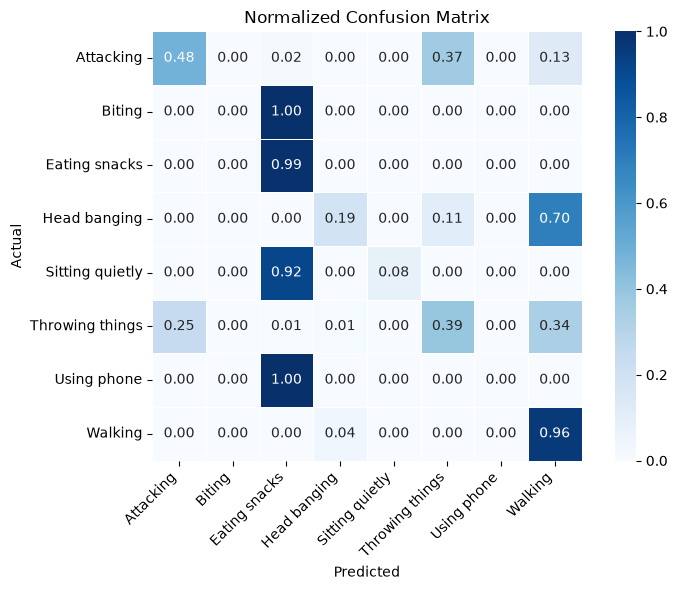

In [13]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using only joint angle features.
# 関節角度特徴量のみを用いてモデルを学習・評価する。
evaluate_supervised(
    X_train_angle_only,
    y_train,
    X_test_angle_only,
    y_test,
    model=rf,
    verbose=True
)

### Normalized Coordinates + Joint Angle Features / 正規化座標 + 関節角度特徴量

This experiment combines the normalized joint coordinates with the extracted joint angle features. The objective is to determine whether geometric angle information provides additional discriminative power beyond the normalized skeleton coordinates alone.

---

### 正規化座標 + 関節角度特徴量

本実験では、正規化した関節座標に関節角度特徴量を追加して評価する。角度特徴量が正規化座標に対して追加の識別能力を提供するかを確認する。

In [18]:
# Combine the normalized coordinates with the extracted joint angle features.
# 正規化した関節座標と抽出した関節角度特徴量を結合する。
X_train_angle = X_train.reset_index(drop=True).join(
    X_train_angle_only.reset_index(drop=True)
)
X_test_angle = X_test.reset_index(drop=True).join(
    X_test_angle_only.reset_index(drop=True)
)

# Summarize the dimensions of the generated datasets.
# 生成したデータセットの形状を要約する。
shape_summary = pd.DataFrame({
    "Dataset": ["X_train_with_angle", "X_test_with_angle", "y_train", "y_test"],
    "Shape": [
        X_train_angle.shape,
        X_test_angle.shape,
        y_train.shape,
        y_test.shape
    ]
})

display(shape_summary)

,Dataset,Shape
0,X_train_with_angle,"(250770, 41)"
1,X_test_with_angle,"(71820, 41)"
2,y_train,"(250770,)"
3,y_test,"(71820,)"



********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.82      0.58      0.68      4530
         Biting       0.01      0.00      0.00      5640
  Eating snacks       0.31      0.98      0.47     14250
   Head banging       0.90      0.29      0.44      3930
Sitting quietly       0.00      0.00      0.00     14910
Throwing things       0.65      0.70      0.67      4050
    Using phone       0.00      0.00      0.00     10200
        Walking       0.80      1.00      0.89     14310

       accuracy                           0.48     71820
      macro avg       0.44      0.44      0.39     71820
   weighted avg       0.36      0.48      0.38     71820


********************************************************************

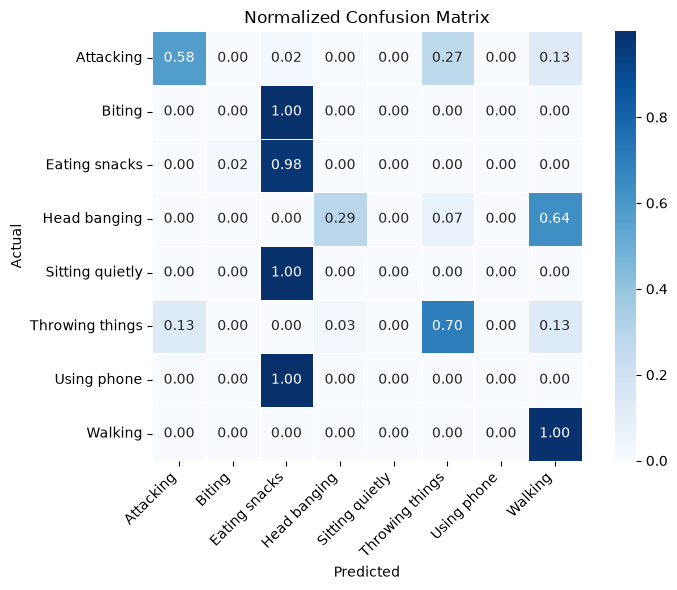

In [21]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using the normalized coordinates
# combined with the extracted joint angle features.
# 正規化した関節座標と抽出した関節角度特徴量を用いて
# モデルを学習・評価する。
evaluate_supervised(
    X_train_angle,
    y_train,
    X_test_angle,
    y_test,
    model=rf
)

## Range of Motion Feature Extraction / 可動域（ROM）特徴量の抽出

This experiment evaluates the contribution of **Range of Motion (ROM)** features to human activity recognition. Unlike joint angles, which describe body posture, ROM features capture the relative positions and movement patterns of key body parts. These features are designed to distinguish activities involving similar postures but different hand positions and movement characteristics.

The extracted features describe wrist position relative to the shoulders, hips, and face, together with measures of hand symmetry. These descriptors are evaluated both independently and in combination with the previously extracted features.

---

## 可動域（ROM）特徴量の抽出

本実験では、**可動域（Range of Motion: ROM）特徴量**が人間行動認識性能に与える影響を評価する。関節角度が身体姿勢を表現するのに対し、ROM特徴量は身体各部位の相対位置や動作の特徴を表現する。これらの特徴量は、姿勢が類似していても手の位置や動きが異なる活動を識別するために設計されている。

抽出する特徴量には、手首と肩・腰・顔との相対位置、および左右の手の対称性が含まれる。これらを単独および既存の特徴量と組み合わせて評価する。

### Range of Motion Features Only / 可動域（ROM）特徴量のみ

This experiment evaluates the discriminative power of the extracted ROM features alone. Only the relative position and movement descriptors are used as input to the baseline classifier.

---

### 可動域（ROM）特徴量のみ

本実験では、抽出したROM特徴量のみを入力として使用し、その識別性能を評価する。相対位置および動作特徴量のみを用いてベースライン分類器を評価する。

In [22]:
# Extract range-of-motion (ROM) features from the training and test datasets.
# 学習データとテストデータから可動域（ROM）特徴量を抽出する。
X_train_rom_only = add_range_of_motion_features(X_train)
X_test_rom_only = add_range_of_motion_features(X_test)

# Display the dimensions of the extracted ROM feature datasets.
# 抽出したROM特徴量データセットの形状を表示する。
shape_summary = pd.DataFrame({
    "Dataset": ["X_train_rom_only", "X_test_rom_only"],
    "Shape": [
        X_train_rom_only.shape,
        X_test_rom_only.shape
    ]
})

display(shape_summary)

# Display a preview of the extracted ROM features.
# 抽出したROM特徴量の内容を表示する。
print_clean_header('X_train_rom_only', border_char='-', line_len=60)
print(X_train_rom_only.head().T.round(2))

print_clean_header('X_test_rom_only', border_char='-', line_len=60)
print(X_test_rom_only.head().T.round(2))

,Dataset,Shape
0,X_train_rom_only,"(250770, 9)"
1,X_test_rom_only,"(71820, 9)"



------------------------------------------------------------
                      X_train_rom_only                      
------------------------------------------------------------
frame_id                            0     1     2     3     4
right_wrist_height_rel_shoulder  1.03  1.04  1.05  1.04  1.01
left_wrist_height_rel_shoulder   1.13  1.15  1.14  1.12  1.10
right_wrist_to_nose_dist         1.40  1.44  1.47  1.50  1.50
left_wrist_to_nose_dist          1.49  1.54  1.56  1.56  1.55
right_wrist_height_rel_hip       0.03  0.04  0.05  0.05  0.02
left_wrist_height_rel_hip        0.13  0.16  0.15  0.12  0.10
wrist_height_asymmetry          -0.10 -0.12 -0.10 -0.07 -0.09
min_wrist_to_nose_dist           1.40  1.44  1.47  1.50  1.50
min_wrist_height_rel_shoulder    1.03  1.04  1.05  1.04  1.01

------------------------------------------------------------
                      X_test_rom_only                       
------------------------------------------------------------
frame_id    


                    Evaluating Model: RandomForestClassifier                    

********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.44      0.49      0.46      4530
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.10      0.14      0.12     14250
   Head banging       0.12      0.07      0.09      3930
Sitting quietly       0.40      0.07      0.12     14910
Throwing things       0.39      0.55      0.45      4050
    Using phone       0.00      0.00      0.00     10200
        Walking       0.36      0.90      0.52     14310

       accuracy                           0.29     71820
      macro avg       0.23      0.28      0.22     71820
   weighted avg       0.23      0.29      0.2

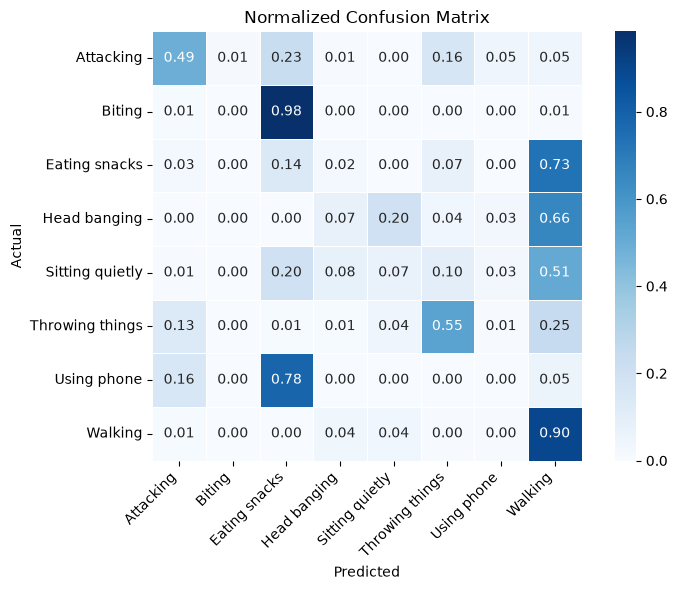

In [23]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using only ROM features.
# ROM特徴量のみを用いてモデルを学習・評価する。
evaluate_supervised(
    X_train_rom_only,
    y_train,
    X_test_rom_only,
    y_test,
    model=rf,
    verbose=True
)

### Normalized Coordinates + Joint Angles + ROM Features / 正規化座標 + 関節角度 + ROM特徴量

This experiment combines the normalized skeleton coordinates, joint angle features, and ROM features. The objective is to determine whether relative motion descriptors provide additional discriminative information beyond skeletal coordinates and body posture.

---

### 正規化座標 + 関節角度 + ROM特徴量

本実験では、正規化したスケルトン座標、関節角度特徴量、およびROM特徴量を組み合わせて評価する。ROM特徴量が姿勢情報に加えて識別性能を向上させるかを確認する。

In [24]:
# Combine the normalized coordinates with the extracted joint angle
# and ROM features.
# 正規化した関節座標に、抽出した関節角度特徴量と
# ROM特徴量を結合する。
X_train_angle_rom = (
    X_train
    .reset_index(drop=True)
    .join(X_train_angle_only.reset_index(drop=True))
    .join(X_train_rom_only.reset_index(drop=True))
)

X_test_angle_rom = (
    X_test
    .reset_index(drop=True)
    .join(X_test_angle_only.reset_index(drop=True))
    .join(X_test_rom_only.reset_index(drop=True))
)

# Summarize the dimensions of the generated datasets.
# 生成したデータセットの形状を要約する。
shape_summary = pd.DataFrame({
    "Dataset": [
        "X_train_with_angle_rom",
        "X_test_with_angle_rom",
        "y_train",
        "y_test"
    ],
    "Shape": [
        X_train_angle_rom.shape,
        X_test_angle_rom.shape,
        y_train.shape,
        y_test.shape
    ]
})

display(shape_summary)

,Dataset,Shape
0,X_train_with_angle_rom,"(250770, 50)"
1,X_test_with_angle_rom,"(71820, 50)"
2,y_train,"(250770,)"
3,y_test,"(71820,)"



********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.84      0.68      0.75      4530
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.32      1.00      0.48     14250
   Head banging       0.89      0.28      0.43      3930
Sitting quietly       0.00      0.00      0.00     14910
Throwing things       0.72      0.70      0.71      4050
    Using phone       0.00      0.00      0.00     10200
        Walking       0.80      0.99      0.89     14310

       accuracy                           0.49     71820
      macro avg       0.45      0.46      0.41     71820
   weighted avg       0.36      0.49      0.38     71820


********************************************************************

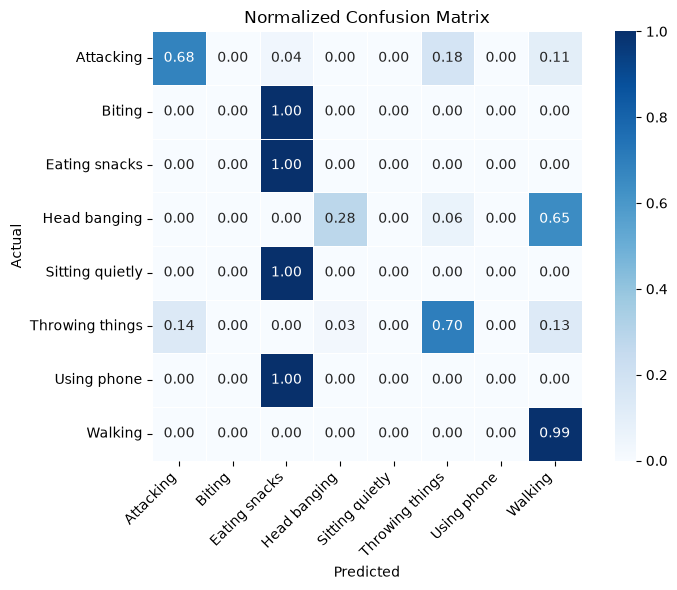

In [25]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using the normalized coordinates
# combined with the extracted joint angle and ROM features.
# 正規化した関節座標に関節角度特徴量とROM特徴量を加えた
# 特徴量を用いてモデルを学習・評価する。
evaluate_supervised(
    X_train_angle_rom,
    y_train,
    X_test_angle_rom,
    y_test,
    model=rf
)

## Velocity and Acceleration Feature Extraction / 速度・加速度特徴量の抽出

This experiment evaluates the contribution of **velocity** and **acceleration** features to human activity recognition. While the previous features describe static body posture and relative joint positions, these temporal features capture **how the body moves over time**.

For each joint coordinate, frame-to-frame velocity is computed using the first-order difference, while acceleration is computed as the second-order difference of the velocity. These features enable the model to distinguish activities with similar postures but different motion dynamics.

---

## 速度・加速度特徴量の抽出

本実験では、**速度**および**加速度**特徴量が人間行動認識性能に与える影響を評価する。これまでの特徴量が身体姿勢や関節の相対位置を表現していたのに対し、本特徴量は**身体が時間的にどのように動くか**を表現する。

各関節座標について、フレーム間の一次差分から速度を、速度の二次差分から加速度を計算する。これにより、姿勢が類似していても動き方が異なる活動を識別できるようになる。

### Velocity and Acceleration Features Only / 速度・加速度特徴量のみ

This experiment evaluates the discriminative power of the extracted velocity and acceleration features alone. Only temporal motion descriptors are used as input to the baseline classifier.

---

### 速度・加速度特徴量のみ

本実験では、抽出した速度・加速度特徴量のみを入力として使用し、その識別性能を評価する。時間的な動作特徴量のみを用いてベースライン分類器を評価する。

In [28]:
# Extract velocity and acceleration features from the training and test datasets.
# 学習データとテストデータから速度・加速度特徴量を抽出する。
X_train_acc_only = add_acceleration_features(X_train)
X_test_acc_only = add_acceleration_features(X_test)

# Display the dimensions of the extracted velocity and acceleration feature datasets.
# 抽出した速度・加速度特徴量データセットの形状を表示する。
shape_summary = pd.DataFrame({
    "Dataset": ["X_train_acc_only", "X_test_acc_only"],
    "Shape": [
        X_train_acc_only.shape,
        X_test_acc_only.shape
    ]
})

display(shape_summary)

# Display a preview of the extracted velocity and acceleration features.
# 抽出した速度・加速度特徴量の内容を表示する。
print_clean_header('X_train_acc_only', border_char='-', line_len=60)
print(X_train_acc_only.head().T.round(2))

print_clean_header('X_test_acc_only', border_char='-', line_len=60)
print(X_test_acc_only.head().T.round(2))

,Dataset,Shape
0,X_train_acc_only,"(250770, 68)"
1,X_test_acc_only,"(71820, 68)"



------------------------------------------------------------
                      X_train_acc_only                      
------------------------------------------------------------
frame_id             0    1     2     3     4
nose_x_vel         0.0  0.0  0.01  0.00  0.03
nose_x_acc         0.0  0.0  0.02 -0.01  0.02
nose_y_vel         0.0  0.0 -0.01 -0.01 -0.02
nose_y_acc         0.0  0.0  0.00 -0.00 -0.01
left_eye_x_vel     0.0  0.0  0.01  0.01  0.03
...                ...  ...   ...   ...   ...
left_ankle_y_acc   0.0  0.0 -0.02 -0.01 -0.00
right_ankle_x_vel  0.0  0.0  0.06  0.05  0.05
right_ankle_x_acc  0.0  0.0  0.02 -0.01 -0.01
right_ankle_y_vel  0.0  0.0 -0.01 -0.03 -0.03
right_ankle_y_acc  0.0  0.0 -0.03 -0.02 -0.01

[68 rows x 5 columns]

------------------------------------------------------------
                      X_test_acc_only                       
------------------------------------------------------------
frame_id             0    1     2    3     4
nose_x_vel  


                    Evaluating Model: RandomForestClassifier                    

********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.72      0.79      0.75      4530
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.34      0.25      0.29     14250
   Head banging       0.83      0.78      0.80      3930
Sitting quietly       0.31      0.20      0.24     14910
Throwing things       0.85      0.44      0.57      4050
    Using phone       0.21      0.47      0.29     10200
        Walking       0.78      0.97      0.86     14310

       accuracy                           0.47     71820
      macro avg       0.50      0.49      0.48     71820
   weighted avg       0.45      0.47      0.4

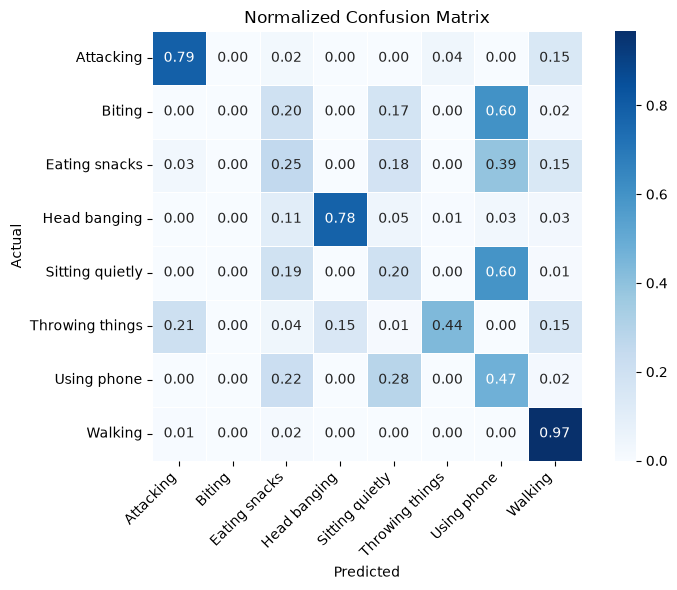

In [29]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using only velocity and acceleration features.
# 速度・加速度特徴量のみを用いてモデルを学習・評価する。
evaluate_supervised(
    X_train_acc_only,
    y_train,
    X_test_acc_only,
    y_test,
    model=rf,
    verbose=True
)

### Normalized Coordinates + Joint Angles + ROM + Velocity & Acceleration / 正規化座標 + 関節角度 + ROM + 速度・加速度特徴量

This experiment combines the normalized skeleton coordinates, joint angle features, ROM features, and temporal motion features. The objective is to evaluate the complete engineered feature set and determine whether motion dynamics further improve activity recognition performance.

---

### 正規化座標 + 関節角度 + ROM + 速度・加速度特徴量

本実験では、正規化したスケルトン座標、関節角度特徴量、ROM特徴量、および速度・加速度特徴量を組み合わせて評価する。すべての設計した特徴量を用い、時間的な動作情報が認識性能をさらに向上させるかを確認する。

In [30]:
# Combine the normalized coordinates with the extracted joint angle,
# ROM, and velocity & acceleration features.
# 正規化した関節座標に、関節角度特徴量、
# ROM特徴量、および速度・加速度特徴量を結合する。
X_train_full = (
    X_train
    .reset_index(drop=True)
    .join(X_train_angle_only.reset_index(drop=True))
    .join(X_train_rom_only.reset_index(drop=True))
    .join(X_train_acc_only.reset_index(drop=True))
)

X_test_full = (
    X_test
    .reset_index(drop=True)
    .join(X_test_angle_only.reset_index(drop=True))
    .join(X_test_rom_only.reset_index(drop=True))
    .join(X_test_acc_only.reset_index(drop=True))
)

# Summarize the dimensions of the generated datasets.
# 生成したデータセットの形状を要約する。
shape_summary = pd.DataFrame({
    "Dataset": [
        "X_train_full",
        "X_test_full",
        "y_train",
        "y_test"
    ],
    "Shape": [
        X_train_full.shape,
        X_test_full.shape,
        y_train.shape,
        y_test.shape
    ]
})

display(shape_summary)

,Dataset,Shape
0,X_train_full,"(250770, 118)"
1,X_test_full,"(71820, 118)"
2,y_train,"(250770,)"
3,y_test,"(71820,)"



********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.85      0.76      0.80      4530
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.31      0.96      0.47     14250
   Head banging       0.94      0.34      0.50      3930
Sitting quietly       0.01      0.00      0.00     14910
Throwing things       0.76      0.70      0.73      4050
    Using phone       0.33      0.00      0.00     10200
        Walking       0.81      1.00      0.90     14310

       accuracy                           0.49     71820
      macro avg       0.50      0.47      0.42     71820
   weighted avg       0.42      0.49      0.39     71820


********************************************************************

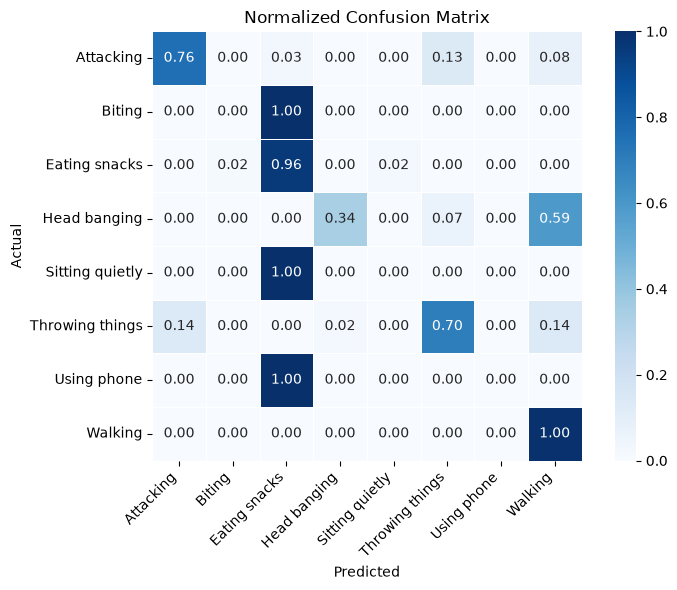

In [31]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using the complete engineered feature set,
# consisting of normalized coordinates, joint angles, ROM,
# and velocity & acceleration features.
# 正規化した関節座標、関節角度特徴量、
# ROM特徴量、および速度・加速度特徴量を組み合わせた
# 完全な特徴量セットを用いてモデルを学習・評価する。
evaluate_supervised(
    X_train_full,
    y_train,
    X_test_full,
    y_test,
    model=rf
)

## Single-scale Window Feature Generation / 単一時間窓特徴量の生成

This experiment aggregates the frame-level features using a single temporal window. Statistical descriptors (mean, standard deviation, minimum, and maximum) are computed over each fixed-length window to summarize the temporal behavior of the activity.

The default configuration is:

- **Window size:** 20 frames
- **Stride:** 10 frames

This experiment serves as a baseline for comparison with the proposed multi-scale windowing approach.

---

## 単一時間窓特徴量の生成

本実験では、フレーム単位の特徴量を単一の時間窓へ集約する。各時間窓について、平均、標準偏差、最小値、および最大値を計算し、時間的特徴量として利用する。

使用するデフォルト設定は以下のとおりである。

- **ウィンドウサイズ:** 20フレーム
- **ストライド:** 10フレーム

本実験は、後に評価するマルチスケール時間窓手法との比較用ベースラインとして用いる。

In [58]:
# Generate single-scale window features from the complete feature set.
# 完全な特徴量セットから単一時間窓特徴量を生成する。
train_single_window = create_windowed_features(
    pd.concat(
        [
            X_train_full,
            y_train.reset_index(drop=True)
        ],
        axis=1
    ),
    window_size=30,
    stride=10
)

test_single_window = create_windowed_features(
    pd.concat(
        [
            X_test_full,
            y_test.reset_index(drop=True)
        ],
        axis=1
    ),
    window_size=30,
    stride=10
)

# Separate the generated windowed datasets into features and labels.
# 生成した単一時間窓データセットを特徴量とラベルに分割する。
X_train_single_window = train_single_window.drop(columns=['Action Label'])
y_train_single_window = train_single_window['Action Label']

X_test_single_window = test_single_window.drop(columns=['Action Label'])
y_test_single_window = test_single_window['Action Label']

# Summarize the dimensions of the generated datasets.
# 生成したデータセットの形状を要約する。
shape_summary = pd.DataFrame({
    "Dataset": [
        "X_train_single_window",
        "X_test_single_window",
        "y_train_single_window",
        "y_test_single_window"
    ],
    "Shape": [
        X_train_single_window.shape,
        X_test_single_window.shape,
        y_train_single_window.shape,
        y_test_single_window.shape
    ]
})

display(shape_summary)

# Display a preview of the generated single-window features.
# 生成した単一時間窓特徴量の内容を表示する。
print_clean_header('X_train_single_window', border_char='-', line_len=60)
print(X_train_single_window.head().T.round(2))

print_clean_header('X_test_single_window', border_char='-', line_len=60)
print(X_test_single_window.head().T.round(2))

/var/folders/k7/84bpl2w97_b120m8mppdd8cc0000gn/T/ipykernel_98879/3236790649.py:3: DeprecationWarning: create_windowed_features() is deprecated. Use create_multiscale_windowed_features() instead.
  train_single_window = create_windowed_features(
/var/folders/k7/84bpl2w97_b120m8mppdd8cc0000gn/T/ipykernel_98879/3236790649.py:15: DeprecationWarning: create_windowed_features() is deprecated. Use create_multiscale_windowed_features() instead.
  test_single_window = create_windowed_features(


,Dataset,Shape
0,X_train_single_window,"(24967, 472)"
1,X_test_single_window,"(7150, 472)"
2,y_train_single_window,"(24967,)"
3,y_test_single_window,"(7150,)"



------------------------------------------------------------
                   X_train_single_window                    
------------------------------------------------------------
                          0     1     2     3     4
nose_x_mean           -0.52 -0.56 -0.58 -0.62 -0.67
nose_y_mean           -1.37 -1.37 -1.38 -1.39 -1.38
left_eye_x_mean       -0.49 -0.54 -0.55 -0.59 -0.64
left_eye_y_mean       -1.43 -1.43 -1.44 -1.44 -1.43
right_eye_x_mean      -0.51 -0.55 -0.56 -0.60 -0.65
...                     ...   ...   ...   ...   ...
left_ankle_y_acc_max   0.11  0.13  0.13  0.13  0.08
right_ankle_x_vel_max  0.07  0.07  0.07  0.07  0.06
right_ankle_x_acc_max  0.07  0.07  0.05  0.05  0.05
right_ankle_y_vel_max  0.10  0.10  0.06  0.07  0.07
right_ankle_y_acc_max  0.09  0.13  0.13  0.13  0.08

[472 rows x 5 columns]

------------------------------------------------------------
                    X_test_single_window                    
---------------------------------------------

### Evaluation of Single-scale Window Features / 単一時間窓特徴量の評価

The complete engineered feature set is transformed into single-scale window features using the default configuration. The resulting statistical feature vectors are evaluated using the baseline Random Forest classifier and later compared with the proposed multi-scale window representation.

---

### 単一時間窓特徴量の評価

完全な特徴量セットをデフォルト設定の単一時間窓特徴量へ変換し、ベースライン Random Forest 分類器で評価する。得られた結果をマルチスケール時間窓特徴量と比較する。


********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.91      0.96      0.93       449
         Biting       0.00      0.00      0.00       560
  Eating snacks       0.32      0.99      0.48      1421
   Head banging       0.99      0.99      0.99       389
Sitting quietly       0.55      0.02      0.03      1487
Throwing things       0.95      0.86      0.91       401
    Using phone       1.00      0.00      0.00      1016
        Walking       0.98      1.00      0.99      1427

       accuracy                           0.56      7150
      macro avg       0.71      0.60      0.54      7150
   weighted avg       0.68      0.56      0.46      7150


********************************************************************

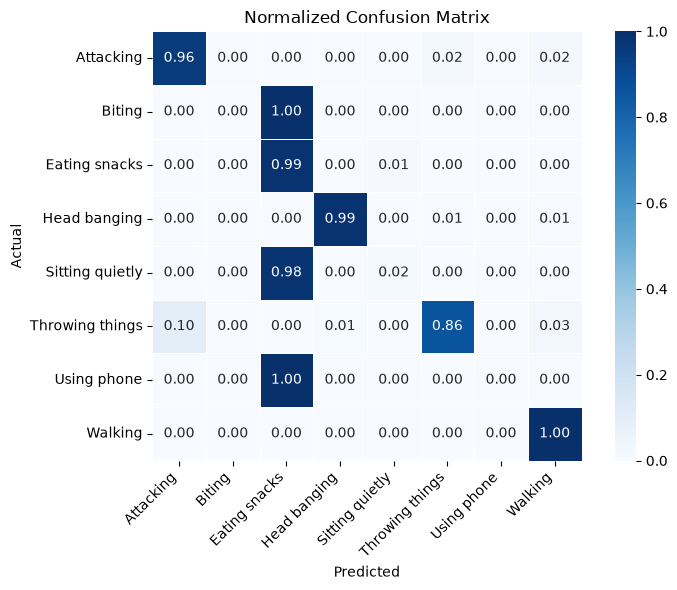

In [59]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using the complete engineered feature set
# aggregated with a single temporal window.
# 完全な特徴量セットを単一時間窓で集約した特徴量を用いて
# モデルを学習・評価する。
evaluate_supervised(
    X_train_single_window,
    y_train_single_window,
    X_test_single_window,
    y_test_single_window,
    model=rf
)

## Leave-One-Subject-Out (LOSO) Evaluation Using Single-Window Features / 単一時間窓特徴量を用いた Leave-One-Subject-Out（LOSO）評価

In [60]:
# Preprocess all subject datasets with single windowing enabled.
# 単一時間窓モードを有効にして、すべての被験者データセットを前処理する。
all_subjec_single_window = preprocess_all_subjects(all_subject=all_subject, single_window_mode=True)

# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using LOSO cross-validation on the single-window features.
# 単一時間窓特徴量を用いてLOSOクロスバリデーションでモデルを学習・評価する。
results = evaluate_loso(all_subjec_single_window, model=rf, verbose='All');

Single windowing mode enabled. Returning single-window features.
Single windowing mode enabled. Returning single-window features.
Single windowing mode enabled. Returning single-window features.
Single windowing mode enabled. Returning single-window features.
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.53      0.16      0.25
  Biting                      0.00      0.00      0.00
  Eating snacks               0.29      0.58      0.39
  Head banging                0.96      0.29      0.45
  Sitting quietly             0.48      0.50      0.49
  Throwing things             0.35      0.62      0.45
  Using phone                 0.25      0.00      0.00
  Walking                     0.80     

## Multi-scale Window Feature Generation / マルチスケール時間窓特徴量の生成

The final feature engineering step aggregates the frame-level features into fixed-length temporal windows. Instead of using individual frames, statistical features are computed over **two temporal scales** to capture both short-term and long-term activity patterns.

For this experiment, the default configuration is:

- **Short window:** 15 frames
- **Long window:** 60 frames
- **Stride:** 10 frames

These default parameters serve as the baseline configuration. Window parameter optimization is performed separately in the subsequent notebook.

---

## マルチスケール時間窓特徴量の生成

最後の特徴量設計では、フレーム単位の特徴量を固定長の時間窓へ集約する。各フレームを個別に扱うのではなく、**短時間窓**と**長時間窓**の2種類の統計特徴量を計算し、短期・長期の動作パターンを同時に表現する。

本実験では、以下のデフォルト設定を使用する。

- **短時間窓:** 15フレーム
- **長時間窓:** 60フレーム
- **ストライド:** 10フレーム

これらはベースライン設定として使用し、時間窓パラメータの最適化は後続のノートブックで実施する。

In [33]:
# Generate multi-scale window features from the complete feature set.
# 完全な特徴量セットからマルチスケール時間窓特徴量を生成する。
train_windowed = create_multiscale_windowed_features(
    pd.concat(
        [
            X_train_full,
            y_train.reset_index(drop=True)
        ],
        axis=1
    ),
    window_sizes=(15, 60),
    stride=10
)

test_windowed = create_multiscale_windowed_features(
    pd.concat(
        [
            X_test_full,
            y_test.reset_index(drop=True)
        ],
        axis=1
    ),
    window_sizes=(15, 60),
    stride=10
)

# Separate the generated windowed datasets into features and labels.
# 生成した時間窓データセットを特徴量とラベルに分割する。
X_train_windowed = train_windowed.drop(columns=['Action Label'])
y_train_windowed = train_windowed['Action Label']

X_test_windowed = test_windowed.drop(columns=['Action Label'])
y_test_windowed = test_windowed['Action Label']

# Summarize the dimensions of the generated datasets.
# 生成したデータセットの形状を要約する。
shape_summary = pd.DataFrame({
    "Dataset": [
        "X_train_windowed",
        "X_test_windowed",
        "y_train_windowed",
        "y_test_windowed"
    ],
    "Shape": [
        X_train_windowed.shape,
        X_test_windowed.shape,
        y_train_windowed.shape,
        y_test_windowed.shape
    ]
})

display(shape_summary)

# Display a preview of the generated windowed features.
# 生成した時間窓特徴量の内容を表示する。
print_clean_header('X_train_windowed', border_char='-', line_len=60)
print(X_train_windowed.head().T.round(2))

print_clean_header('X_test_windowed', border_char='-', line_len=60)
print(X_test_windowed.head().T.round(2))

,Dataset,Shape
0,X_train_windowed,"(24802, 944)"
1,X_test_windowed,"(7102, 944)"
2,y_train_windowed,"(24802,)"
3,y_test_windowed,"(7102,)"



------------------------------------------------------------
                      X_train_windowed                      
------------------------------------------------------------
                               0     1     2     3     4
short_nose_x_mean          -0.48 -0.55 -0.56 -0.58 -0.62
short_nose_y_mean          -1.36 -1.37 -1.37 -1.37 -1.40
short_left_eye_x_mean      -0.46 -0.52 -0.54 -0.56 -0.59
short_left_eye_y_mean      -1.42 -1.43 -1.43 -1.43 -1.45
short_right_eye_x_mean     -0.48 -0.54 -0.55 -0.57 -0.59
...                          ...   ...   ...   ...   ...
long_left_ankle_y_acc_max   0.13  0.13  0.13  0.13  0.11
long_right_ankle_x_vel_max  0.07  0.07  0.07  0.07  0.07
long_right_ankle_x_acc_max  0.07  0.07  0.05  0.08  0.08
long_right_ankle_y_vel_max  0.10  0.10  0.07  0.24  0.24
long_right_ankle_y_acc_max  0.13  0.13  0.13  0.33  0.33

[944 rows x 5 columns]

------------------------------------------------------------
                      X_test_windowed         


********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.98      0.97      0.98       443
         Biting       0.00      0.00      0.00       554
  Eating snacks       0.31      0.97      0.47      1415
   Head banging       1.00      1.00      1.00       383
Sitting quietly       0.00      0.00      0.00      1481
Throwing things       0.96      0.97      0.97       395
    Using phone       0.00      0.00      0.00      1010
        Walking       1.00      1.00      1.00      1421

       accuracy                           0.56      7102
      macro avg       0.53      0.61      0.55      7102
   weighted avg       0.43      0.56      0.46      7102


********************************************************************

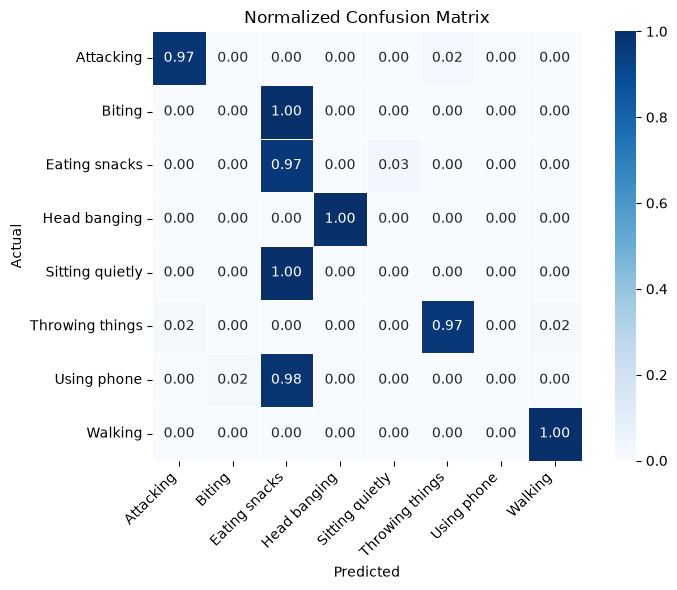

In [34]:
# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using the complete engineered feature set,
# consisting of normalized coordinates, joint angles, ROM,
# and velocity & acceleration features.
# 正規化した関節座標、関節角度特徴量、
# ROM特徴量、および速度・加速度特徴量を組み合わせた
# 完全な特徴量セットを用いてモデルを学習・評価する。
evaluate_supervised(
    X_train_windowed,
    y_train_windowed,
    X_test_windowed,
    y_test_windowed,
    model=rf
)

## Leave-One-Subject-Out (LOSO) Evaluation Using Multi-Window Features / マルチスケール時間窓特徴量を用いた Leave-One-Subject-Out（LOSO）評価

In [53]:
# Preprocess all subject datasets with multi-scale windowing enabled.
# マルチスケール時間窓モードを有効にして、すべての被験者データセットを前処理する。
all_subject_multi_window = preprocess_all_subjects(all_subject=all_subject)

# Initialize the baseline Random Forest classifier.
# ベースラインのRandom Forest分類器を初期化する。
rf = model_random_forest()

# Train and evaluate the model using LOSO cross-validation on the multi-scale window features.
# マルチスケール時間窓特徴量を用いてLOSOクロスバリデーションでモデルを学習・評価する。
results = evaluate_loso(all_subject_multi_window, model=rf, verbose='All');

Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.58      0.10      0.18
  Biting                      0.00      0.00      0.00
  Eating snacks               0.31      0.82      0.45
  Head banging                0.24      0.29      0.27
  Sitting quietly             0.17      0.04      0.06
  Throwing things             0.41      0.82      0.55
  Using phone                 0.00      0.00      0.00
  Walking                     0.86      0.99      0.92

  Macro F1: 0.303
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 2  |  Train: ['1', '3', '5'] 
----------------------------------------------------
  Class            

## Feature Distribution Analysis / 特徴量分布の分析

The distribution of **`right_wrist_to_nose_dist_mean`** was compared across all subjects for the **Biting** activity. Although the feature consistently captures the expected behavior of the hand remaining close to the face, noticeable differences exist between subjects.

### Key Observations

- **Subject 3** exhibits the largest variation, indicating more diverse hand movements during the activity.
- **Subjects 2 and 5** show highly concentrated distributions, suggesting more consistent wrist positions.
- **Subject 1** presents moderate variability with several higher-distance values.
- Overall, the same activity is performed differently by different subjects, resulting in distinct feature distributions.

### Conclusion

The feature is effective for representing the **Biting** activity; however, its distribution is subject-dependent. This inter-subject variability explains why models trained on a limited number of subjects may struggle to generalize to unseen individuals, reinforcing the need for subject-independent evaluation and training using multiple participants.

---

## 特徴量分布の分析

**Biting** 動作における **`right_wrist_to_nose_dist_mean`** の分布を被験者ごとに比較した。その結果、この特徴量は手が顔に近いという動作特性を適切に表現している一方で、被験者間で分布に明確な違いが見られた。

### 主な観察結果

- **Subject 3** は最も広い分布を示し、手の動きにばらつきが大きい。
- **Subjects 2** および **5** は分布が集中しており、手首位置が比較的一定である。
- **Subject 1** は中程度のばらつきを示し、一部に距離の大きいサンプルが存在する。
- 同じ動作であっても、被験者ごとに特徴量分布が異なることが確認できた。

### 結論

本特徴量は **Biting** を表現する有効な特徴量であるが、その分布は被験者によって異なる。このような被験者間のばらつきは、少数の被験者のみで学習したモデルの汎化性能を低下させる要因となり、複数被験者による学習や **LOSO（Leave-One-Subject-Out）交差検証** の必要性を裏付ける結果となった。# Feature Distribution Analysis

## Objective

The goal of visualizing these feature distributions was to determine whether the engineered window-level features can explain the confusion observed between the following activities:

- Biting
- Eating snacks
- Using phone
- Sitting quietly

Each feature was plotted separately for every subject to observe both **class separability** and **inter-subject variability**.

---

# 1. Strong Inter-Subject Variability

The most obvious observation is that the same activity often produces very different feature distributions across different subjects.

For example, the feature:

- `long_angle_right_elbow_mean`

shows substantially different elbow angle distributions for the **Using phone** activity depending on the subject.

Examples include:

- Subjects whose elbow angles cluster around 120°–170°
- Subjects with peaks near 70°
- Subjects exhibiting bimodal distributions

This indicates that the model cannot simply learn:

> "Using phone corresponds to elbow angle = X"

because the value of X changes considerably from person to person.

### Conclusion

Inter-subject variability is stronger than class variability for many posture-based features.

---

# 2. Sitting Quietly is Well Separated

Across nearly every feature, the **Sitting quietly** class exhibits:

- Very low wrist motion
- Near-zero standard deviations
- Stable wrist height
- Minimal elbow movement

Examples include:

- `short_right_wrist_to_nose_dist_std`
- `long_angle_right_elbow_std`

These distributions are tightly concentrated near zero.

### Conclusion

This class is expected to be relatively easy for the classifier to identify.

---

# 3. Biting and Eating Snacks Show Significant Overlap

These two classes consistently exhibit similar distributions for several posture-based features.

Examples include:

- `short_right_wrist_to_nose_dist_mean`
- `long_right_wrist_height_rel_shoulder_mean`
- `long_angle_right_elbow_mean`

Both activities involve:

- Hand positioned near the face
- Bent elbow
- Similar wrist height
- Similar average hand-to-face distance

### Conclusion

Static posture alone is insufficient to distinguish biting from eating.

---

# 4. Wrist-to-Nose Distance is Informative

The feature:

- `short_right_wrist_to_nose_dist_mean`

shows the clearest separation among the evaluated posture features.

General observations:

- Sitting quietly tends to have the largest wrist-to-face distances.
- Using phone occupies an intermediate range.
- Eating snacks and Biting generally have shorter distances.

Although overlap remains, this feature contains useful discriminative information.

### Conclusion

This feature should remain in the feature set.

---

# 5. Standard Deviation Features Capture Motion

The standard deviation features provide insight into movement intensity.

For example:

- `short_right_wrist_to_nose_dist_std`

shows:

### Sitting quietly

- Very close to zero
- Almost no movement

### Using phone

- Small variance
- Hand remains relatively stationary

### Eating snacks

- Larger spread
- Increased movement due to repeated hand-to-mouth cycles

This agrees well with the expected biomechanics of each activity.

### Conclusion

Windowed motion statistics appear more informative than static posture measurements.

---

# 6. Elbow Angle Standard Deviation is Less Informative

The feature:

- `long_angle_right_elbow_std`

was expected to distinguish activities based on elbow motion.

However, nearly all subjects and classes exhibit:

- Large spikes near zero
- Similar overall distributions

Only the distribution tails differ.

### Conclusion

This feature contributes relatively little discriminative information.

---

# Overall Findings

The engineered features are not inherently poor.

Rather, most of them describe **static posture** rather than **activity dynamics**.

The difficult classes:

- Biting
- Eating snacks
- Using phone

share similar arm configurations but differ primarily in **how the hand moves over time**, not where it is located.

Current features primarily measure:

- Mean joint angles
- Mean wrist height
- Mean wrist-to-face distance

These descriptors are insufficient to capture temporal behaviour.

---

# Implications for Feature Engineering

To better distinguish these activities, future features should emphasize movement patterns rather than static posture.

Potential temporal features include:

- Wrist speed mean
- Wrist speed standard deviation
- Wrist acceleration statistics
- Number of hand-to-mouth cycles
- Number of wrist-to-face transitions
- Percentage of frames where the wrist remains near the mouth
- Duration of hand-near-face events
- Frequency of oscillatory wrist motion

These descriptors are expected to better separate:

- Eating snacks (repeated hand-to-mouth cycles)
- Biting (small repetitive hand movements near the mouth)
- Using phone (hand near face with relatively little movement)

---

# Final Conclusion

The visualizations suggest that the current feature set captures **where the hand is**, but not **how it moves**.

This explains why the classifier performs well on activities such as **Sitting quietly**, yet struggles to distinguish between **Biting**, **Eating snacks**, and **Using phone**, which are primarily differentiated by their temporal movement patterns rather than static body posture.

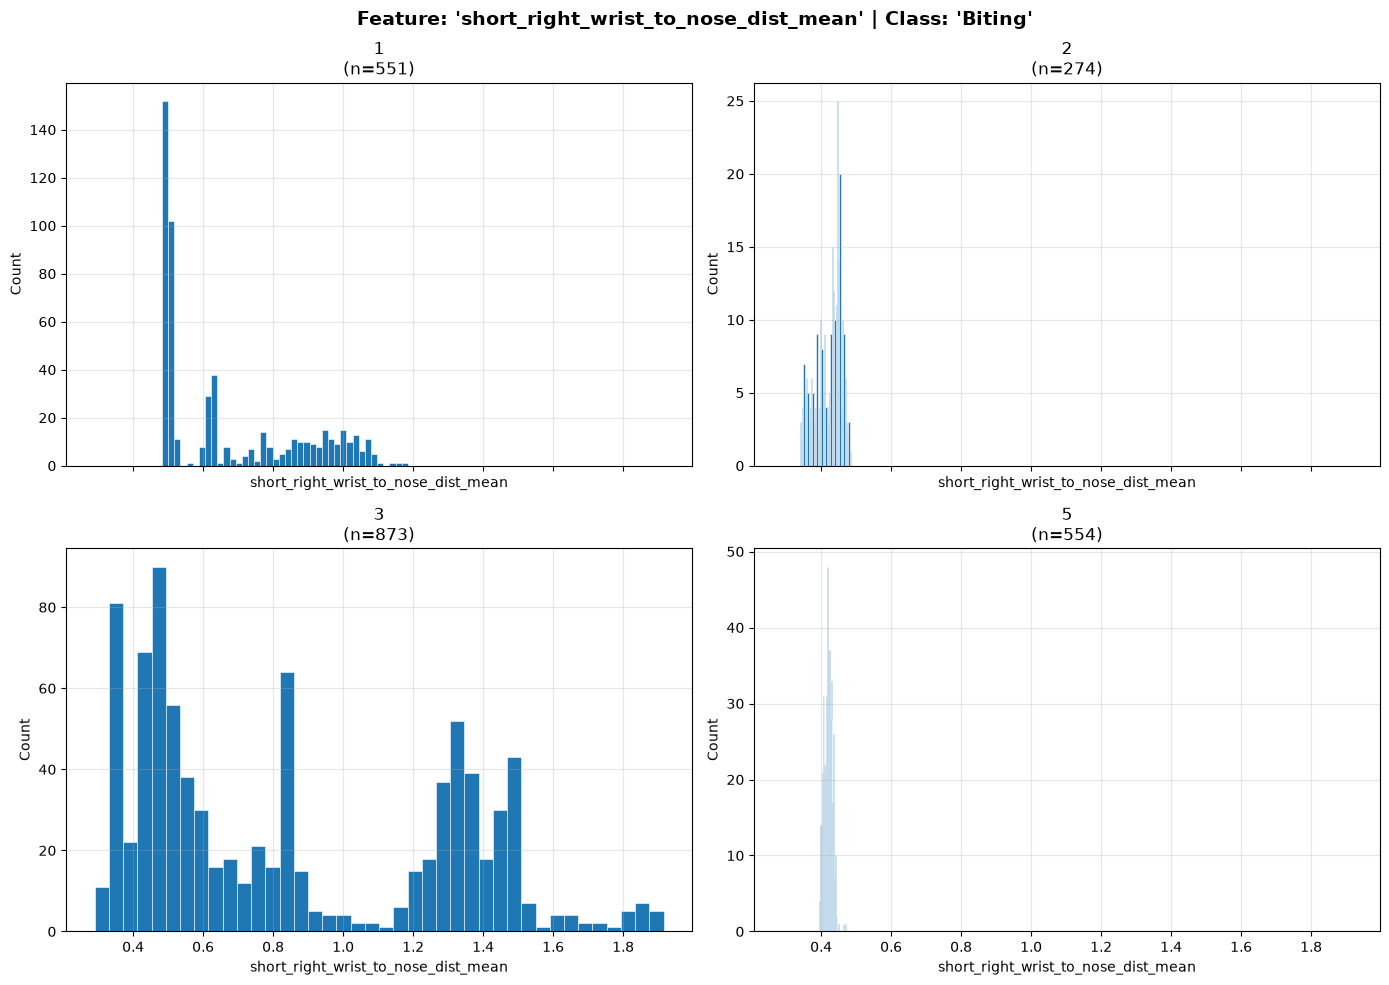

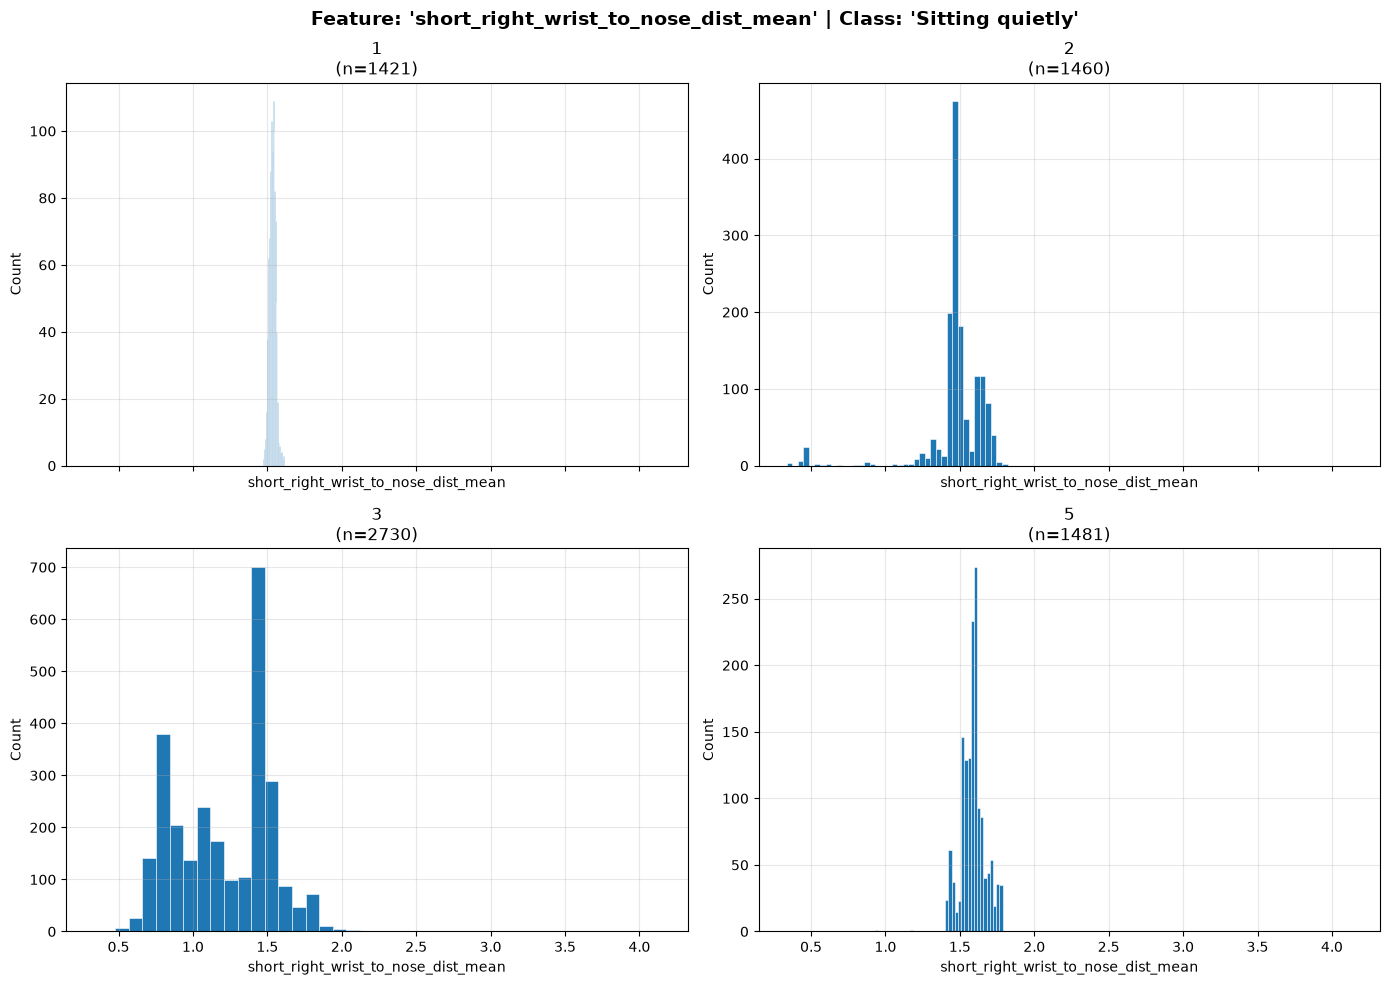

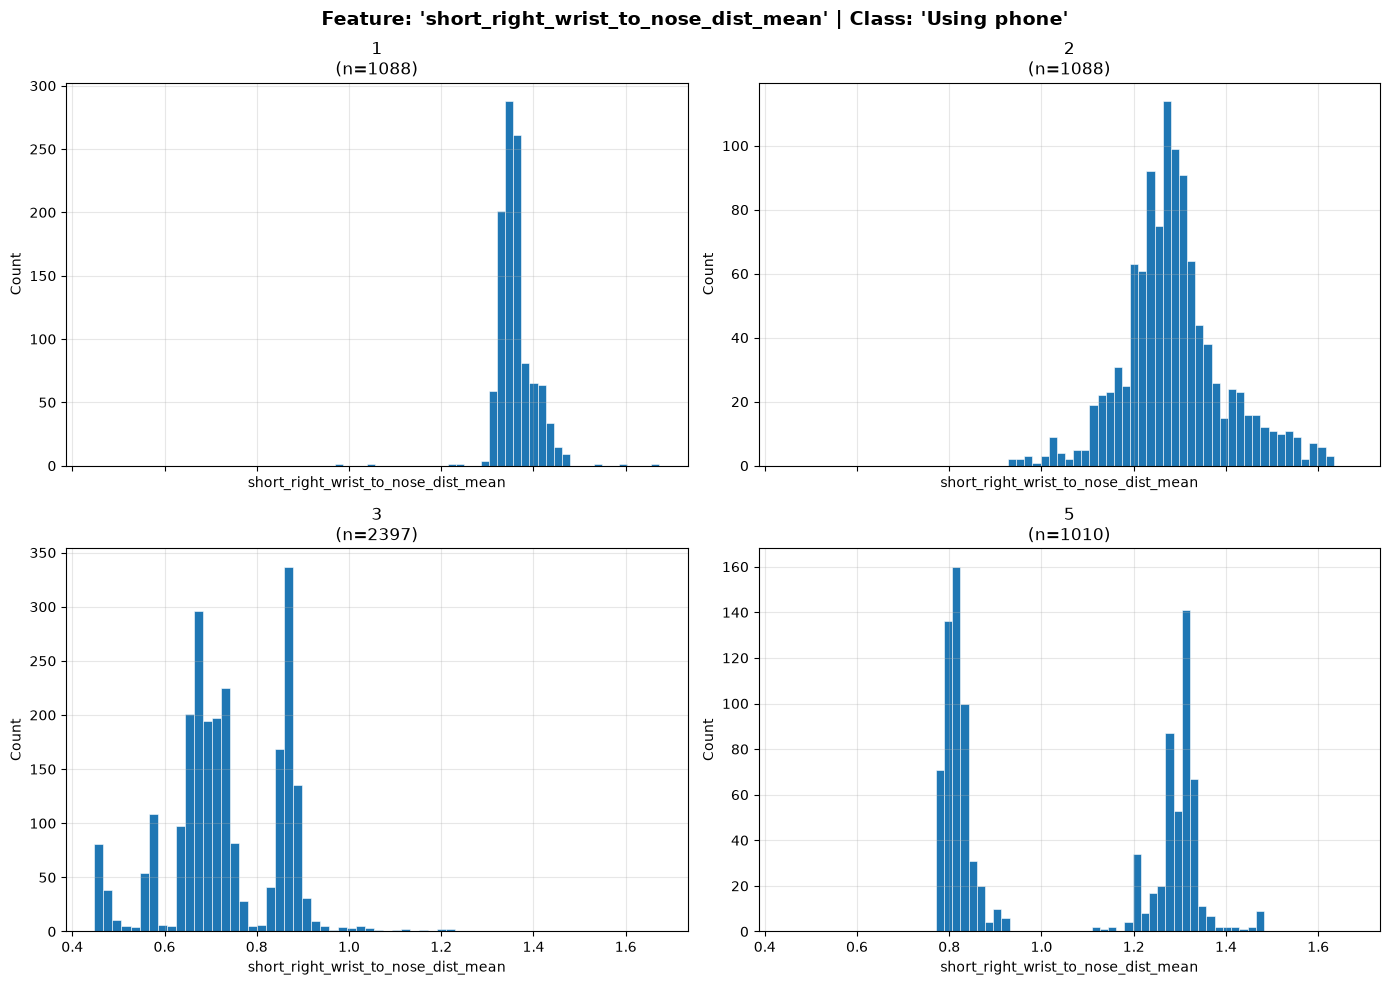

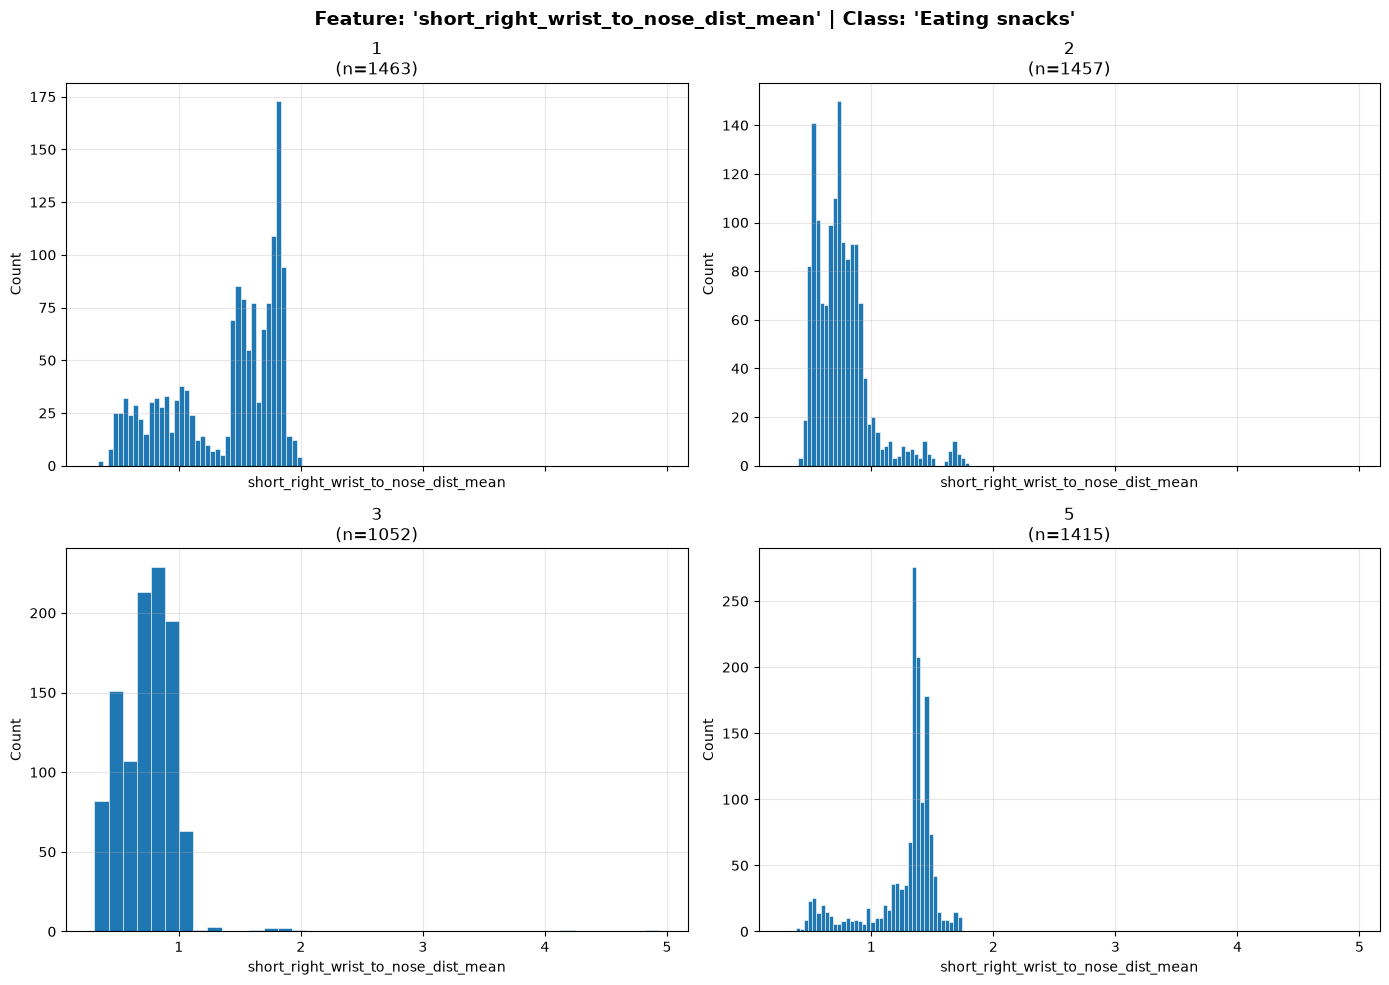

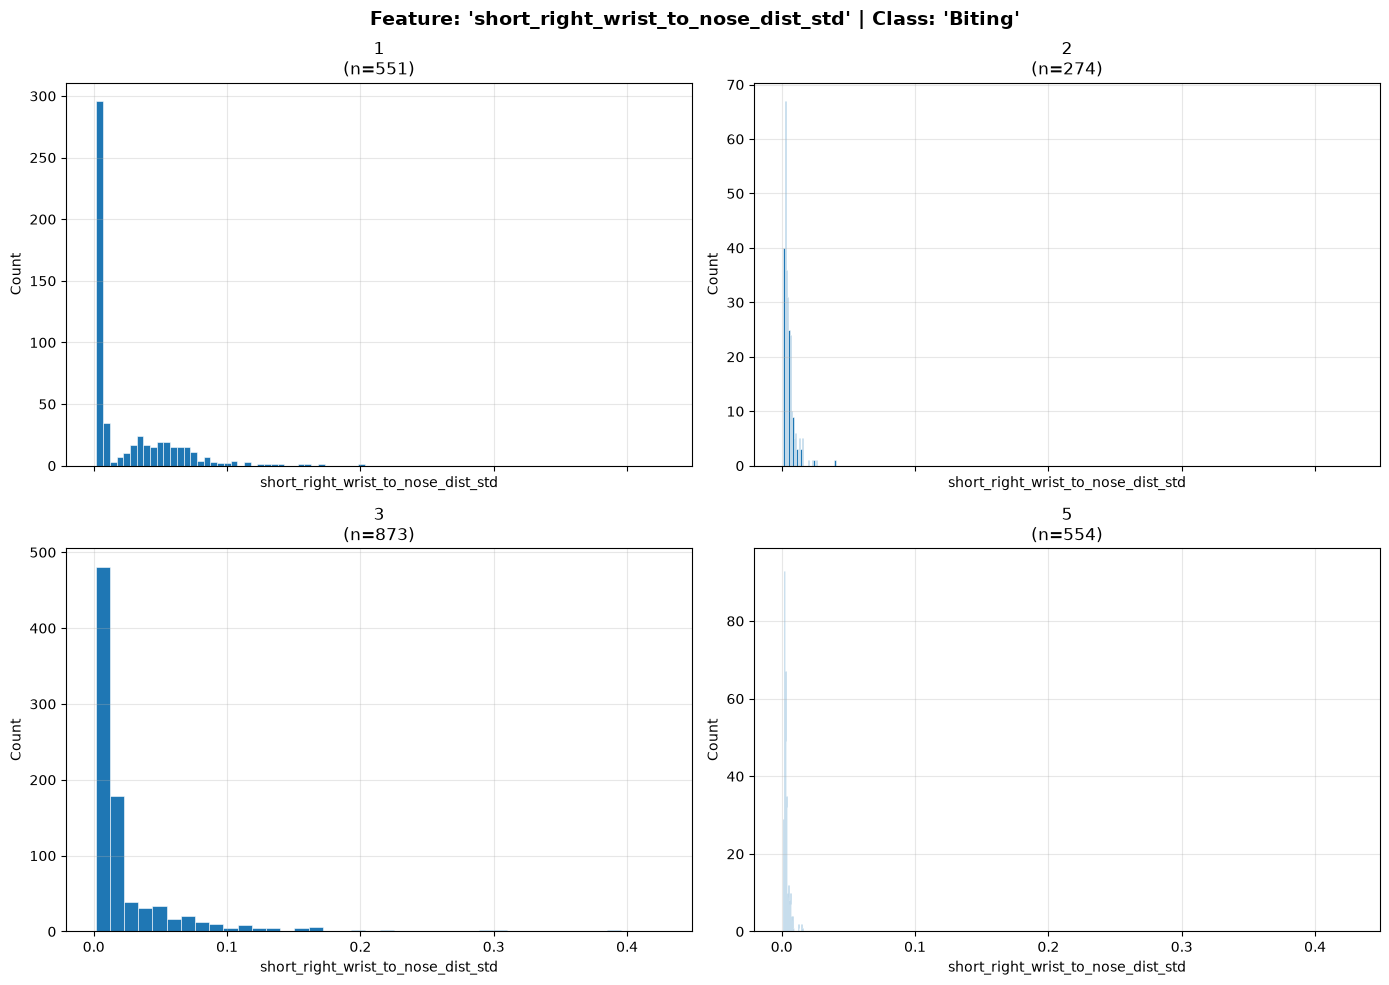

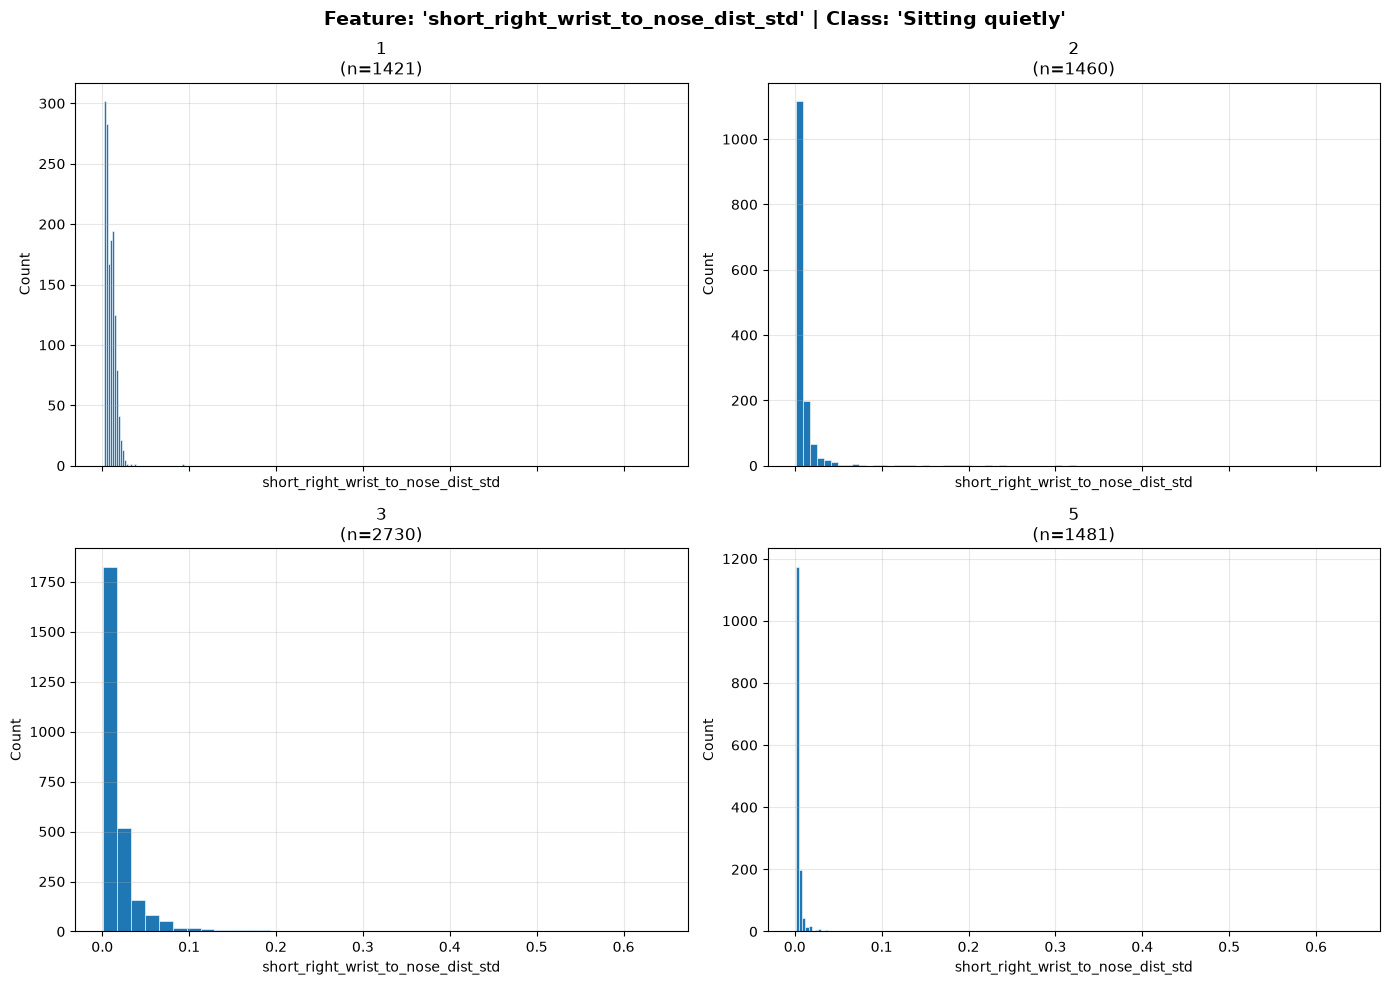

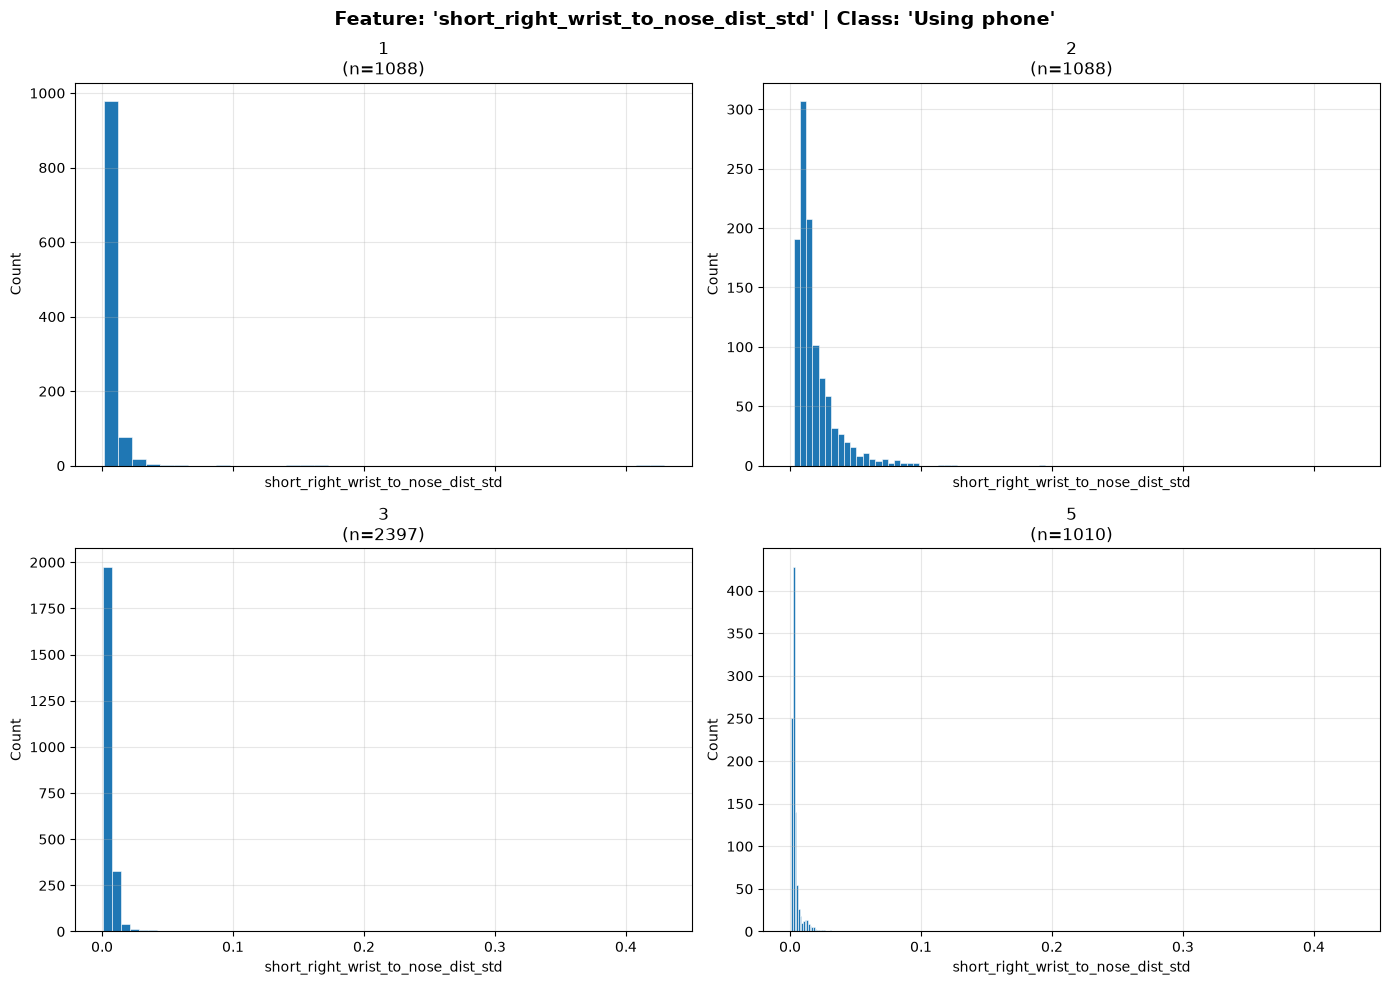

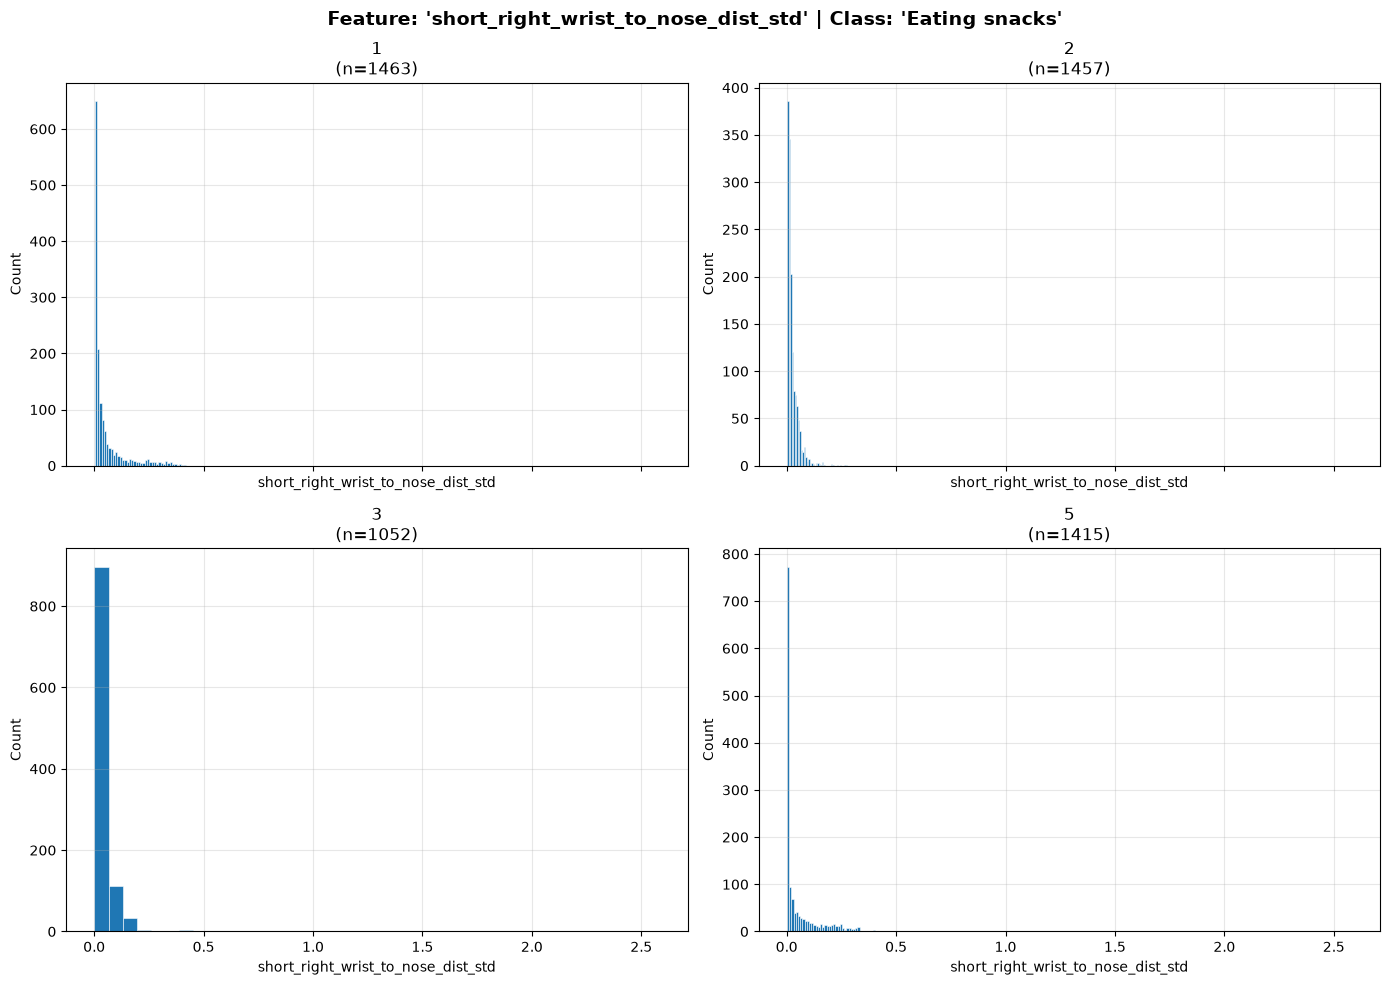

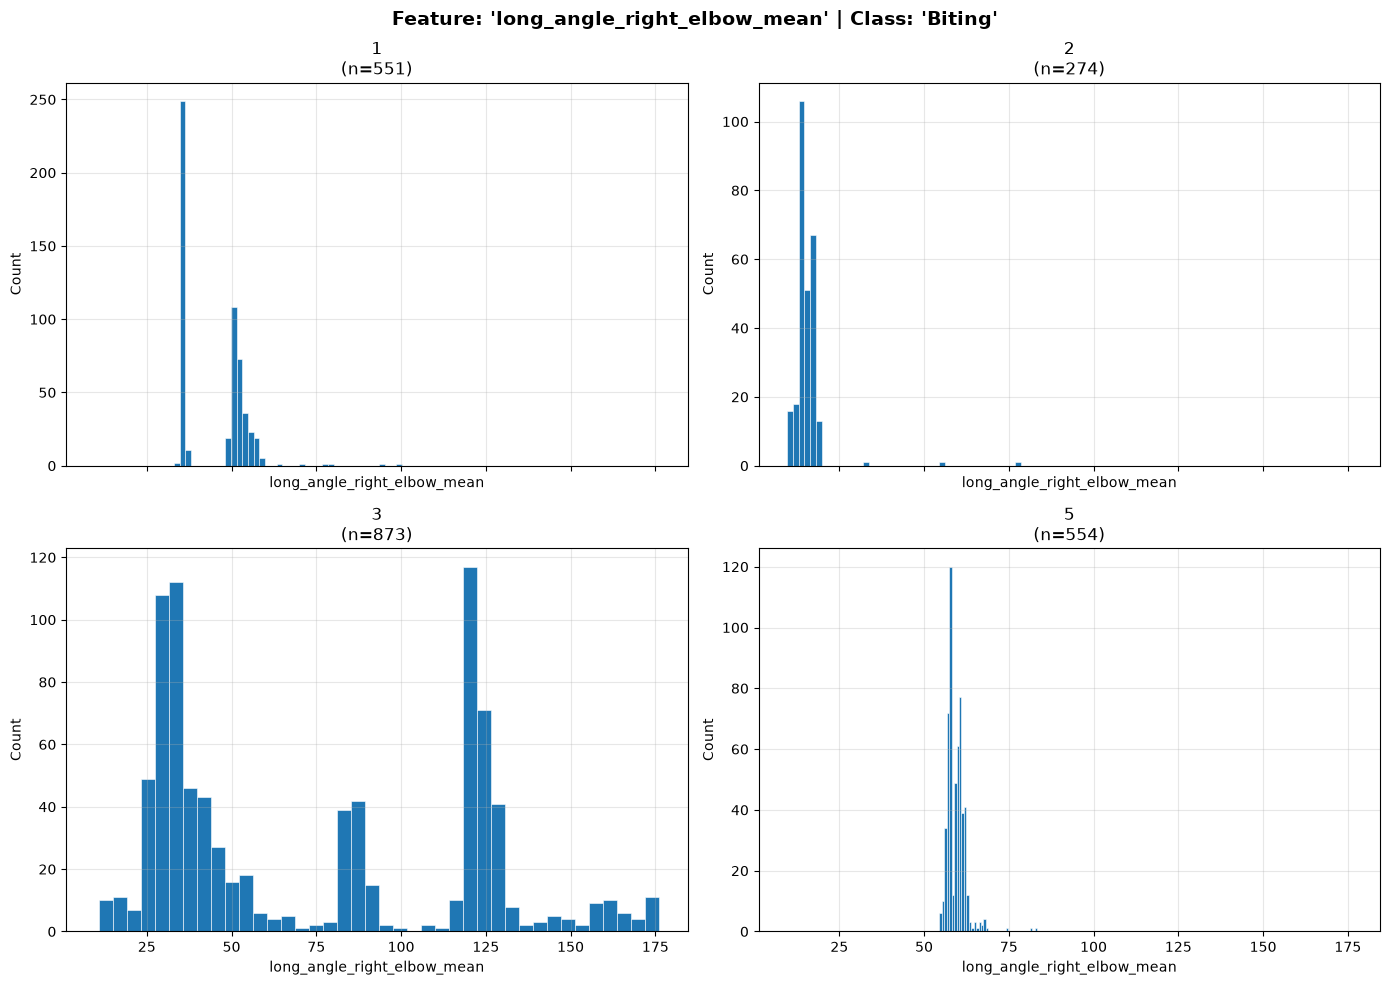

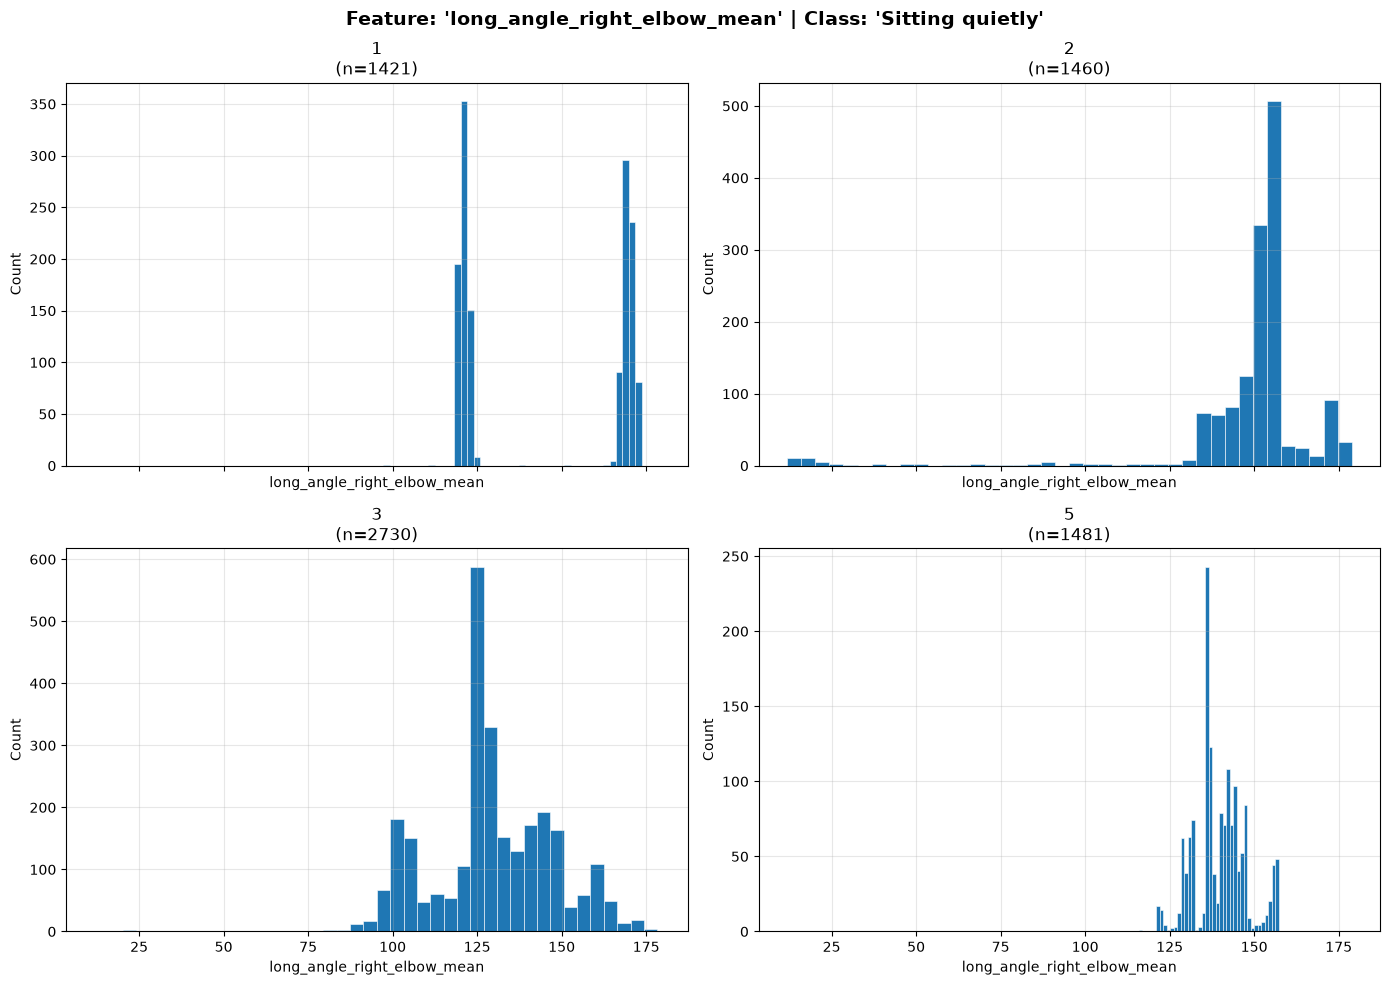

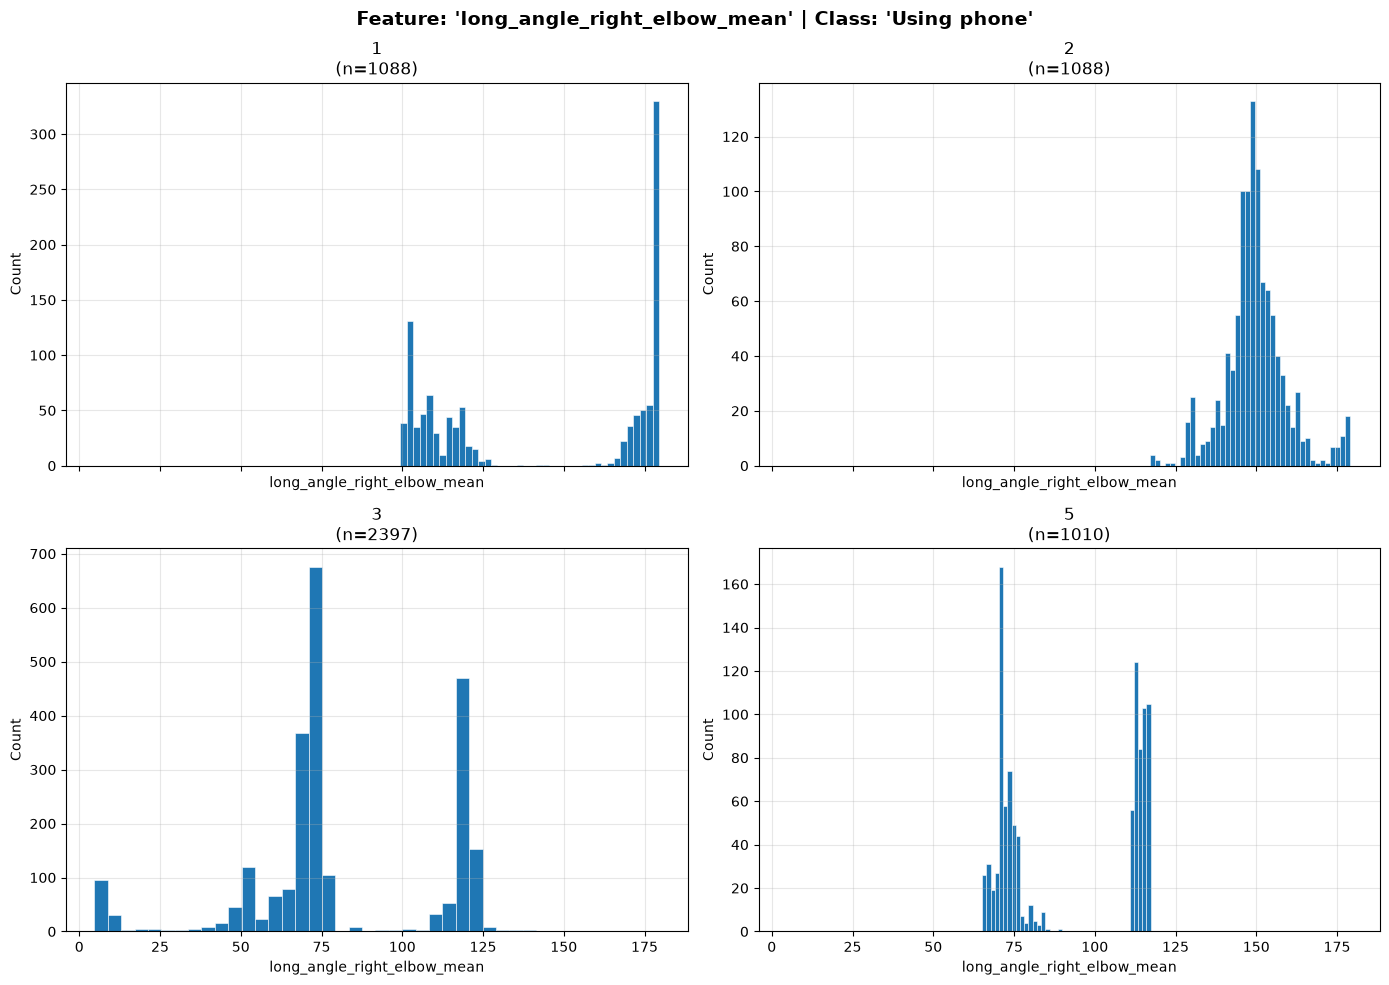

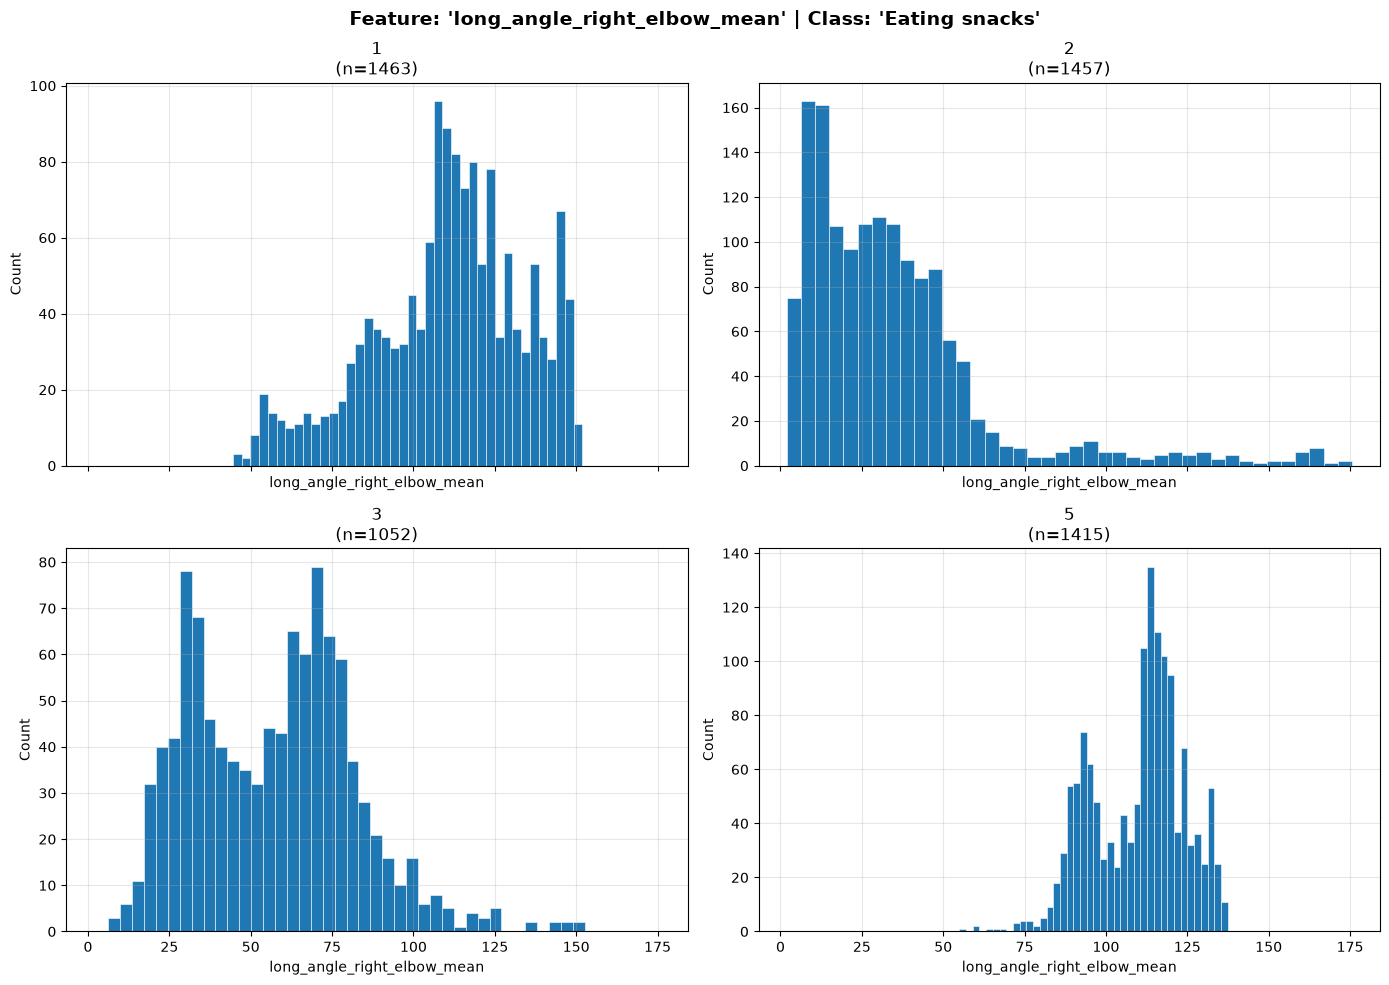

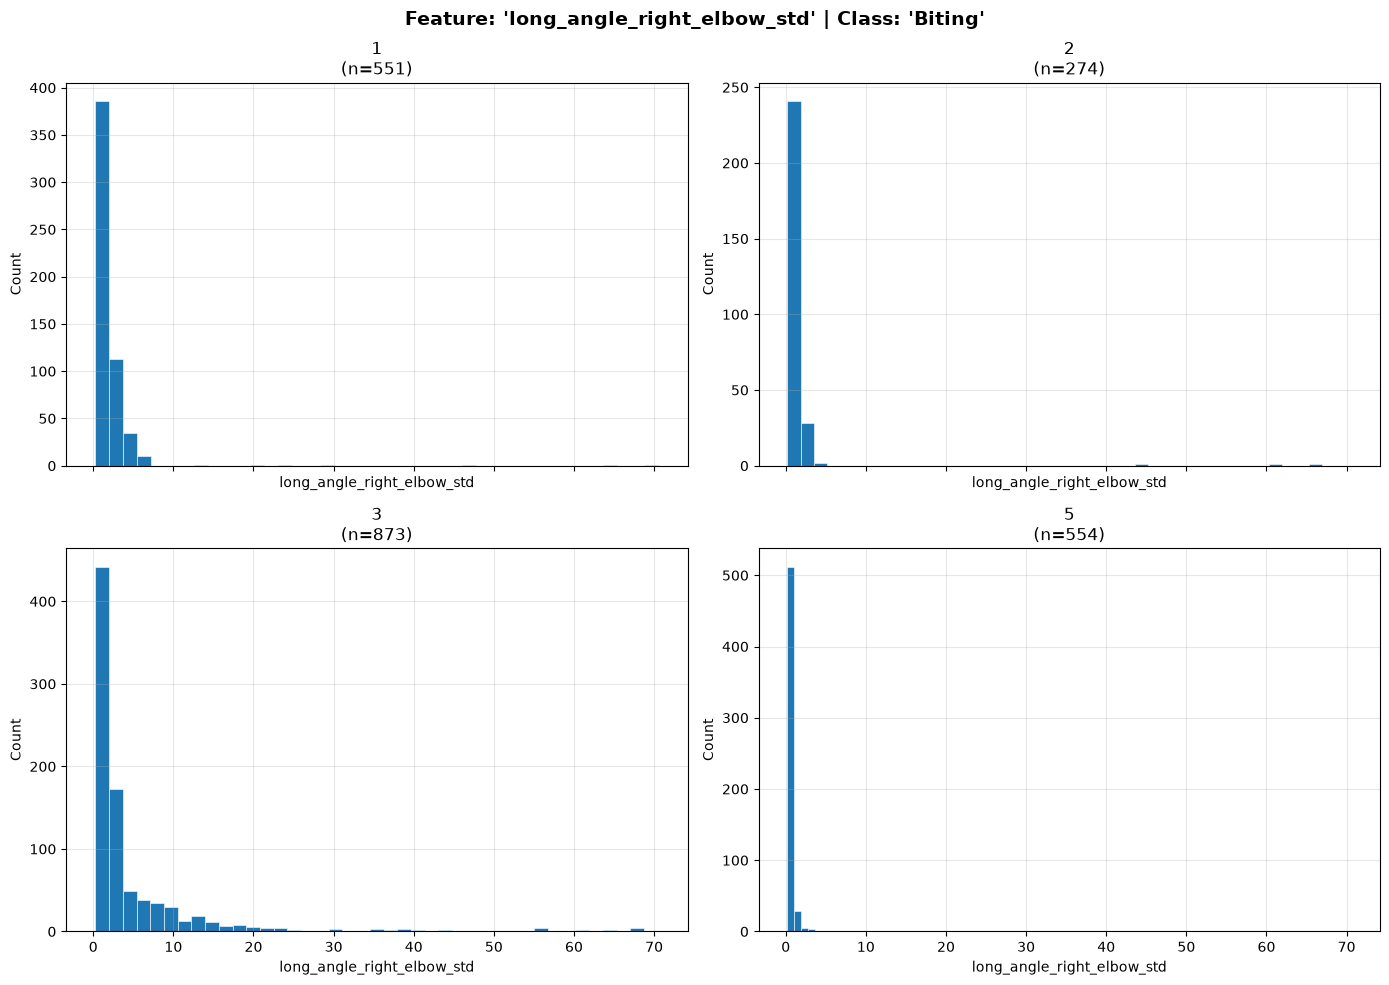

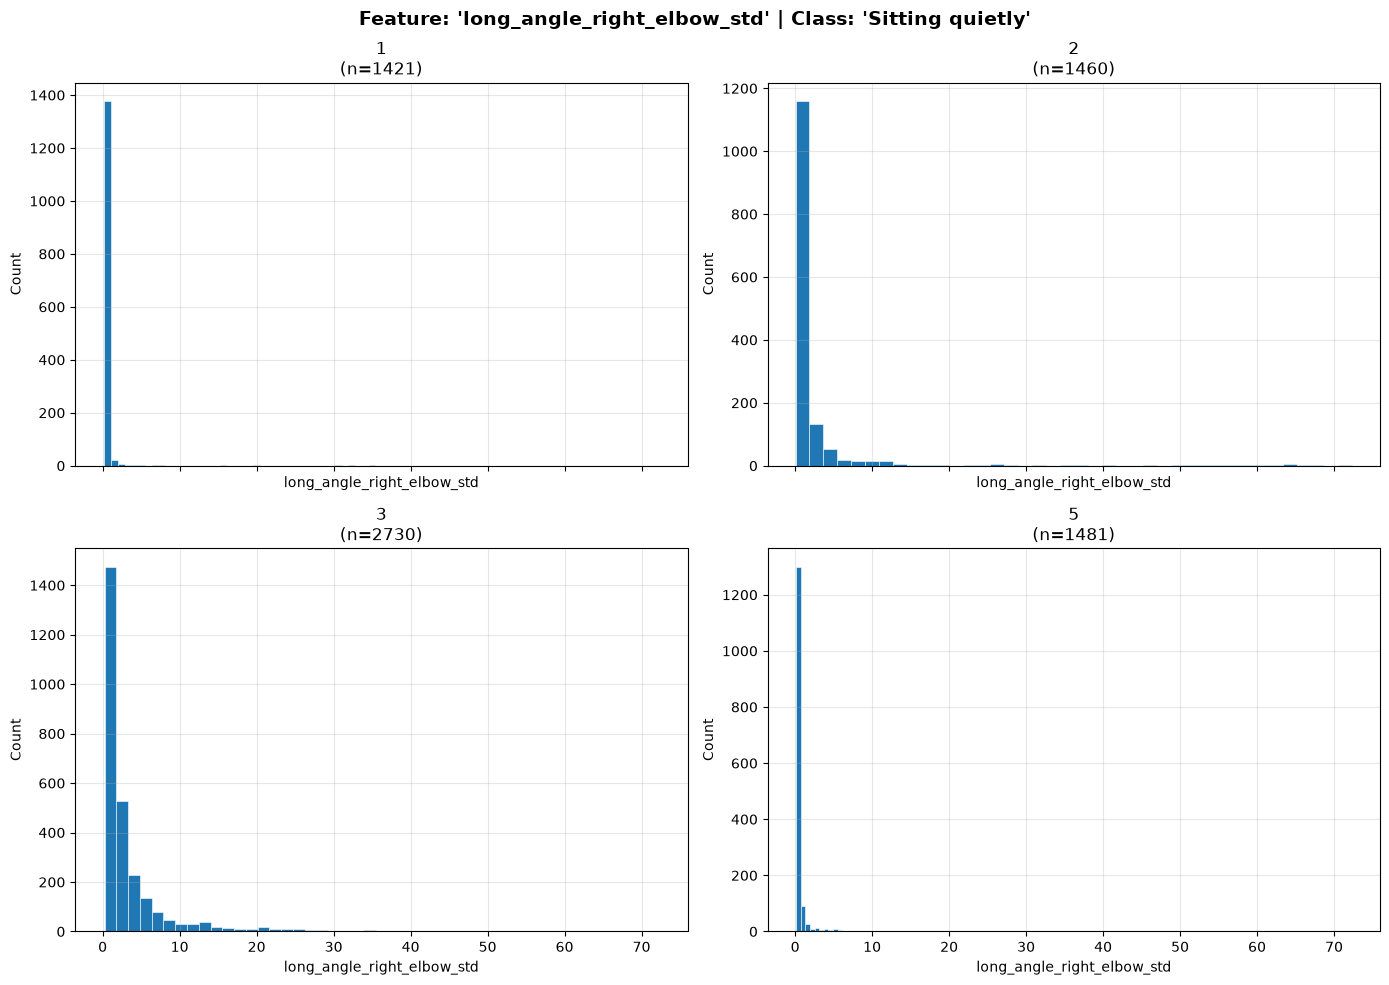

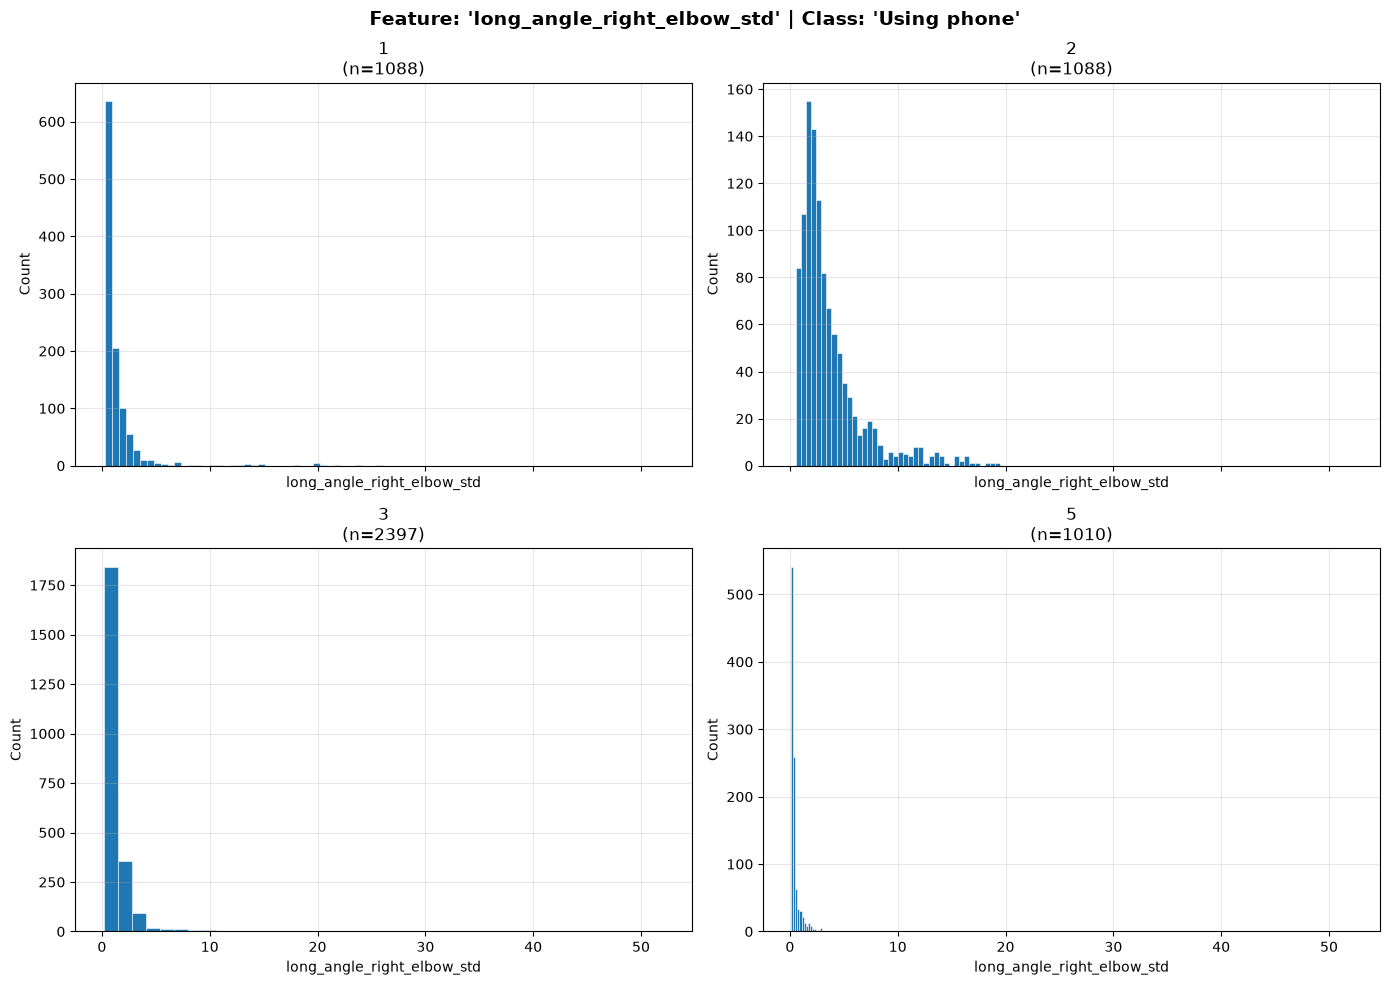

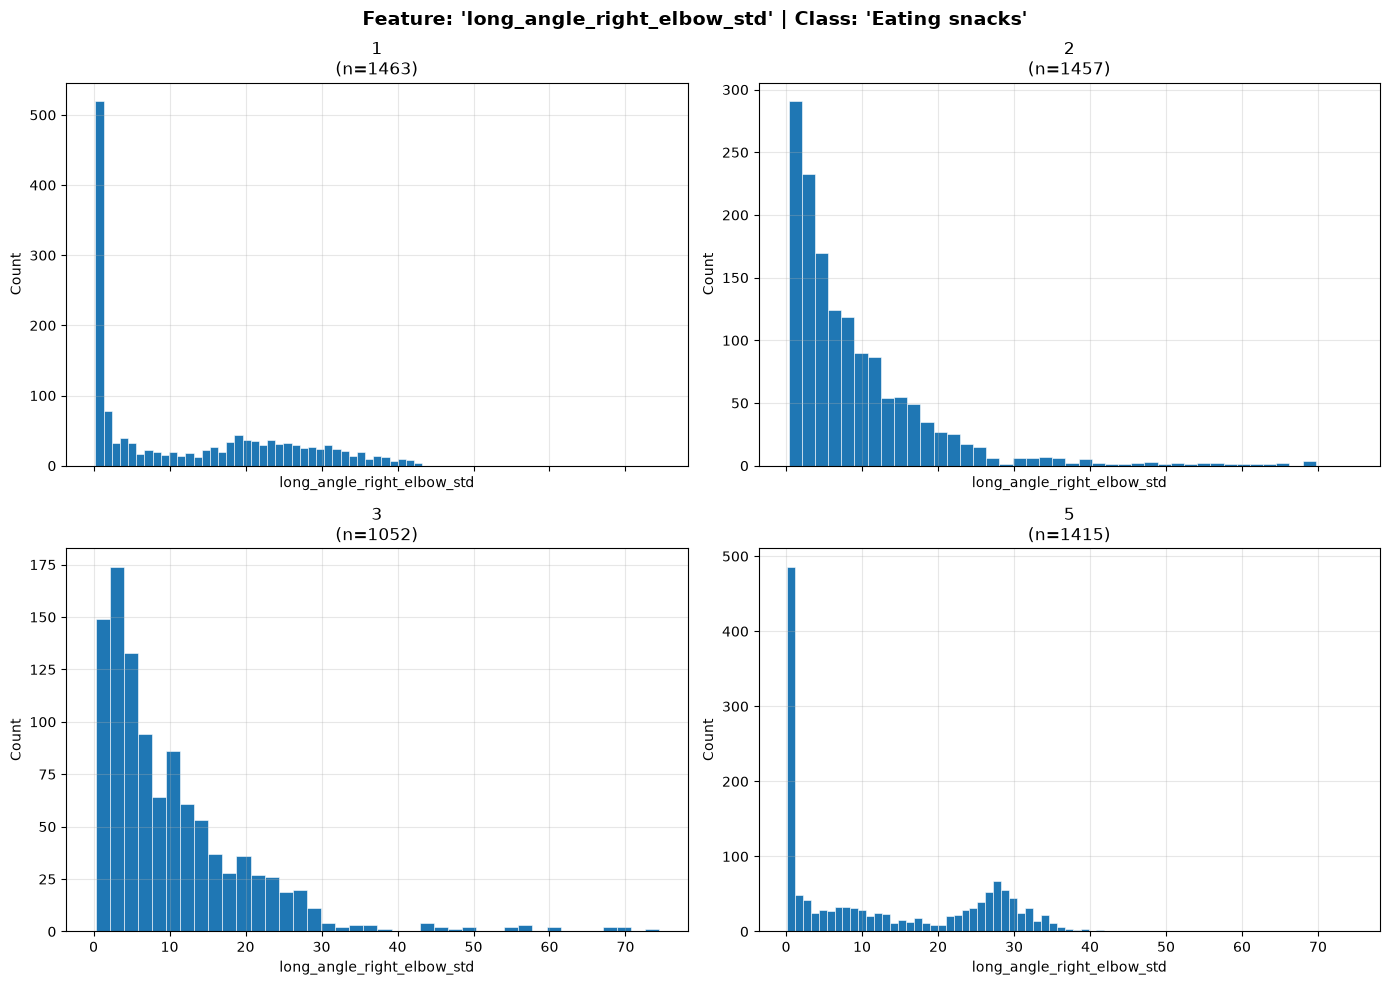

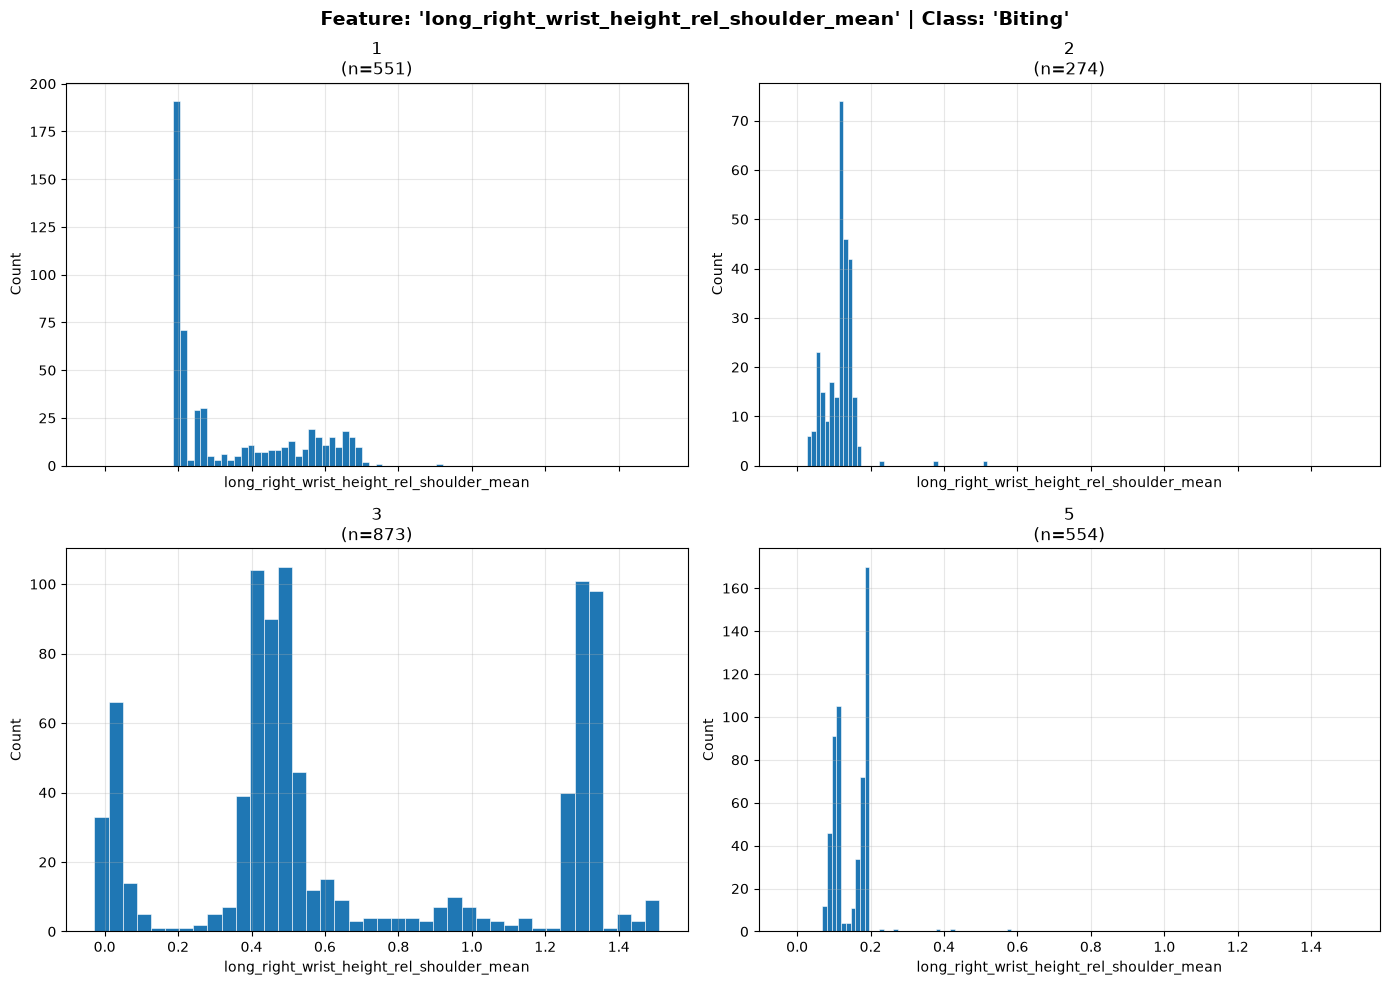

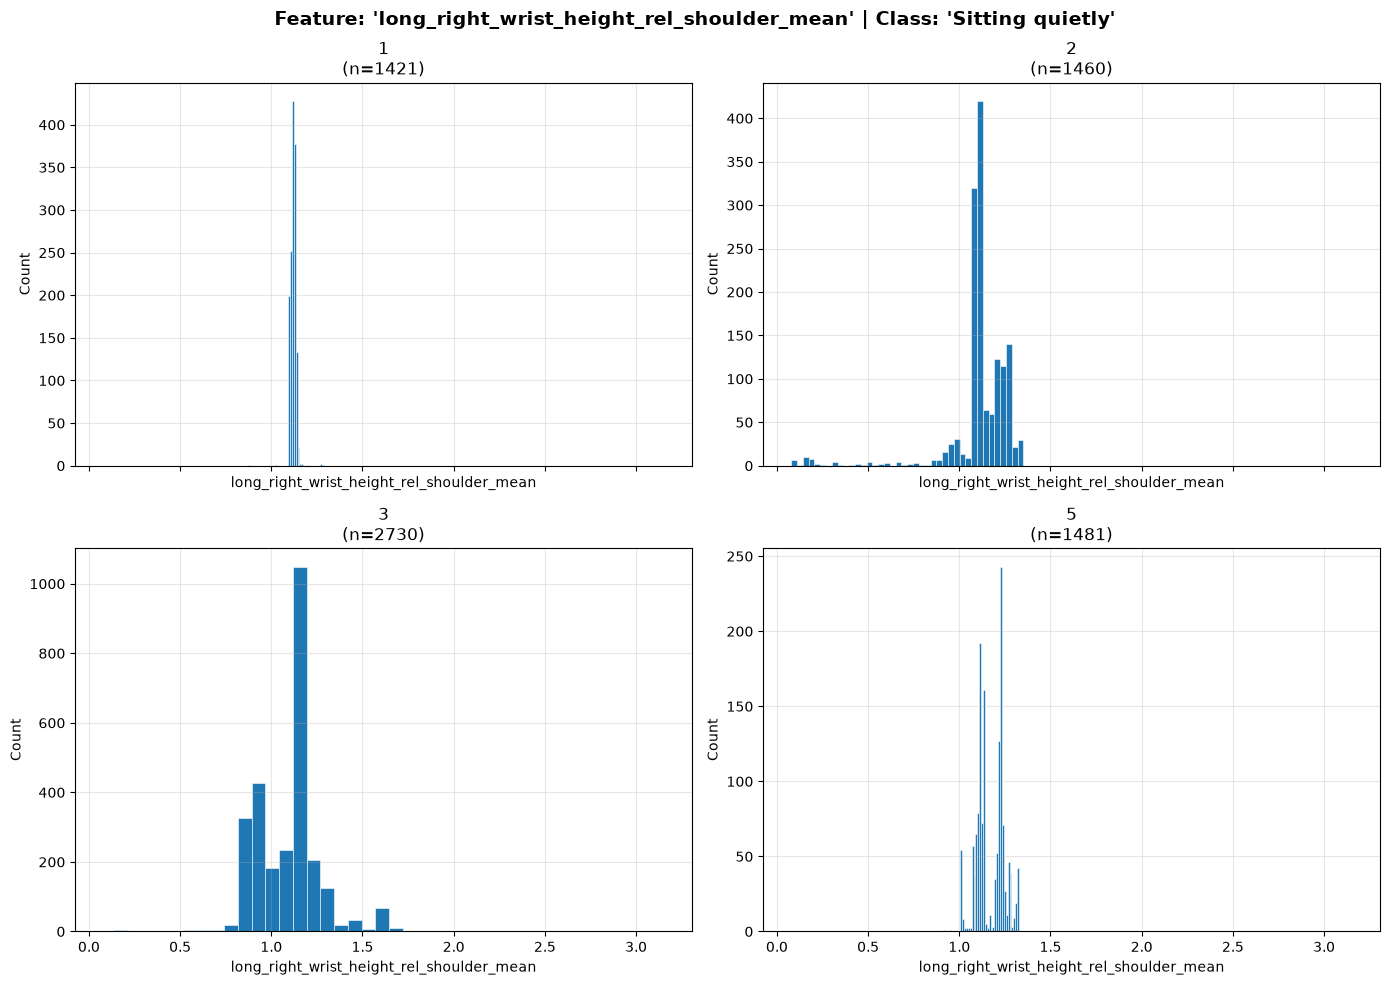

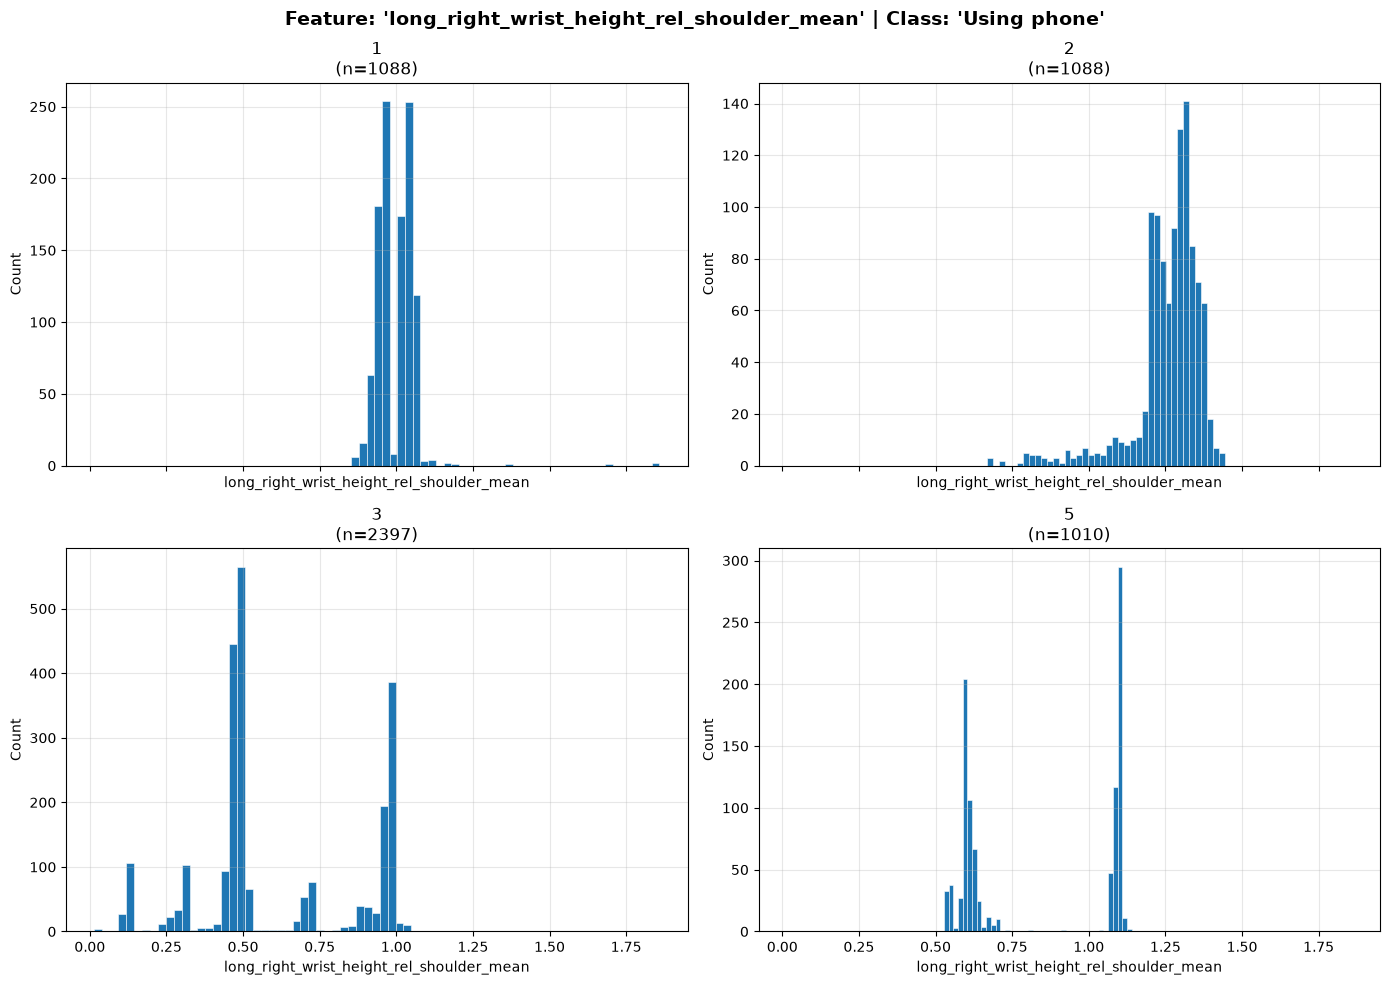

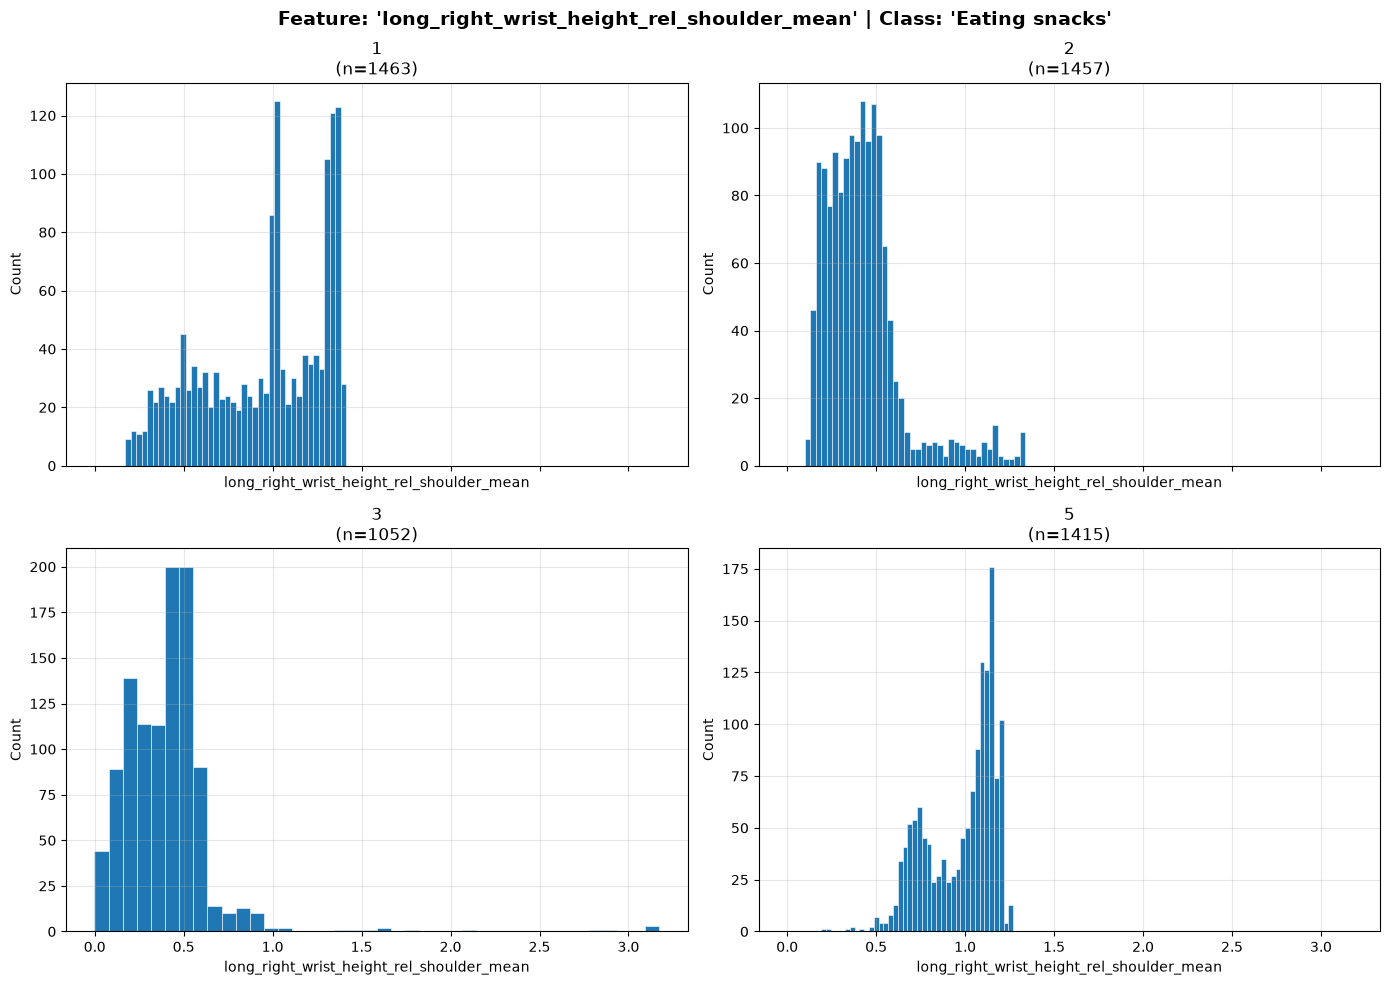

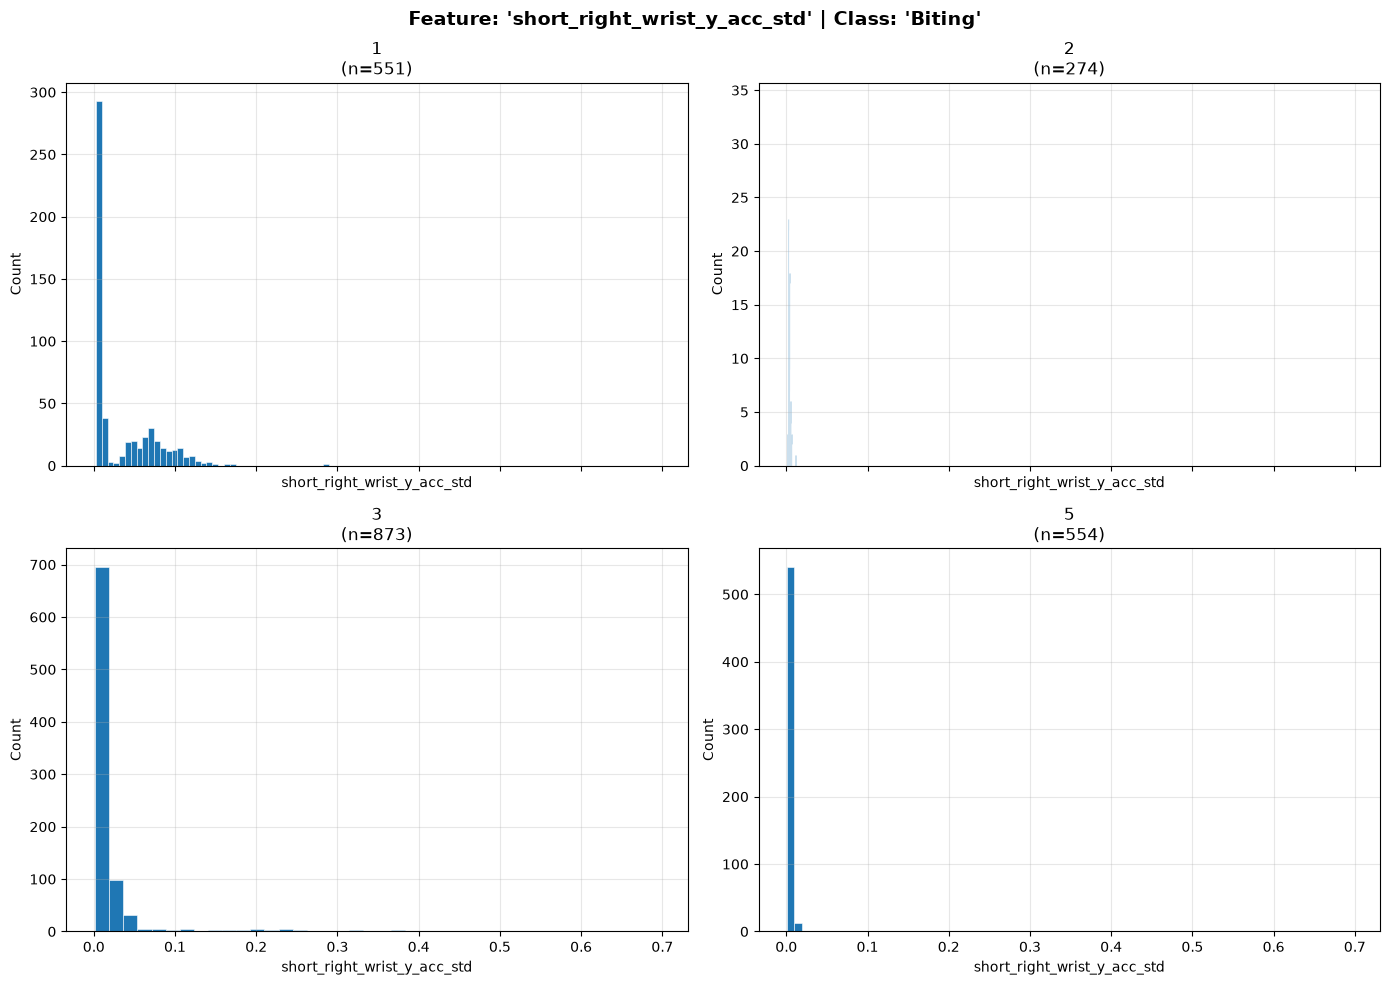

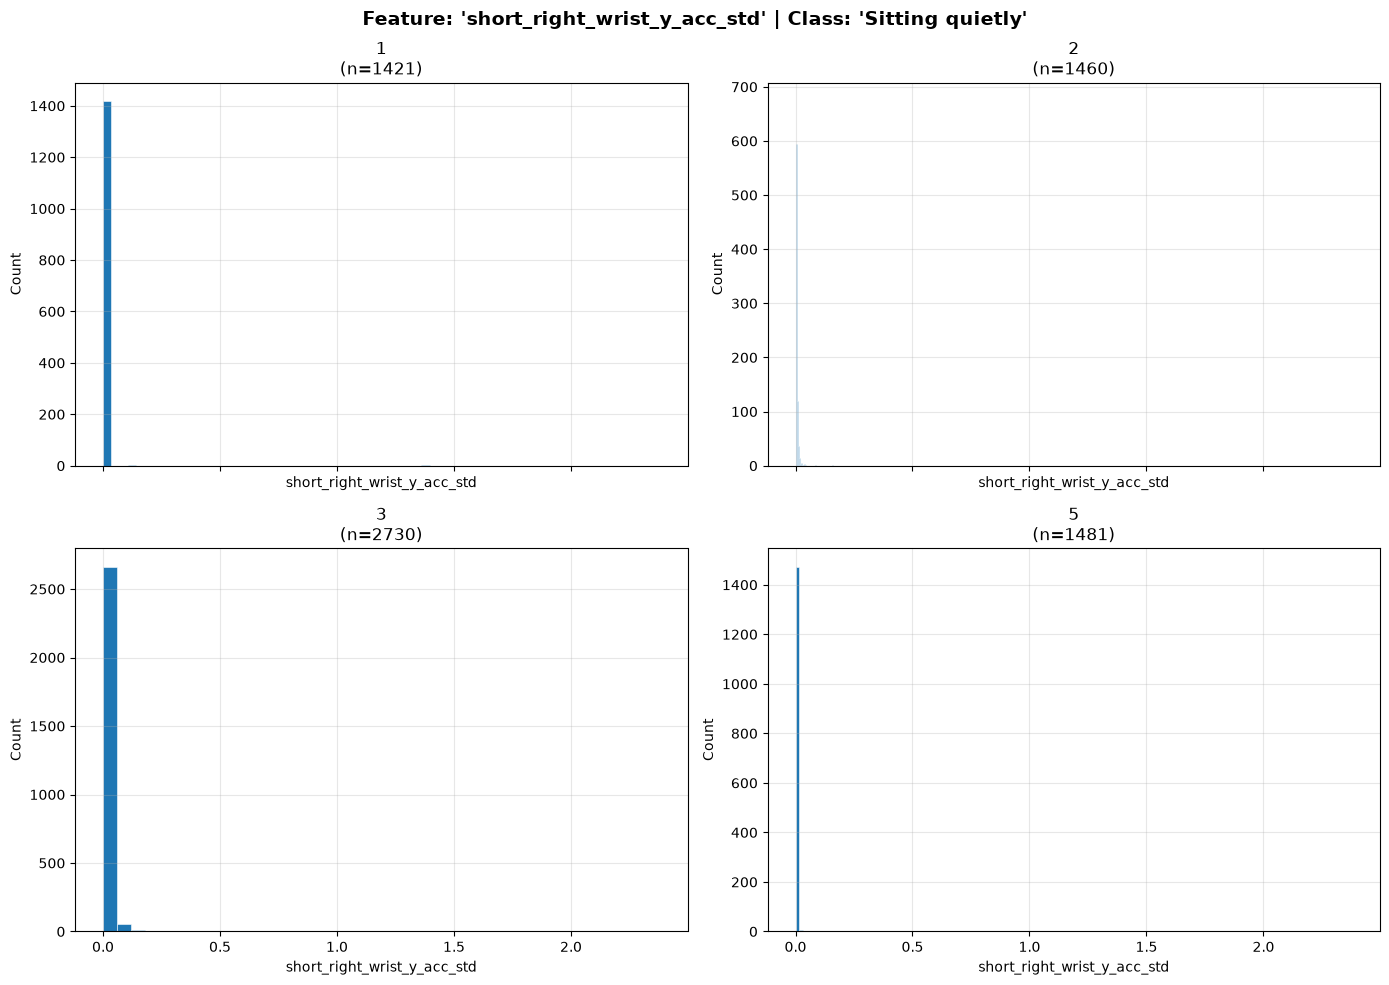

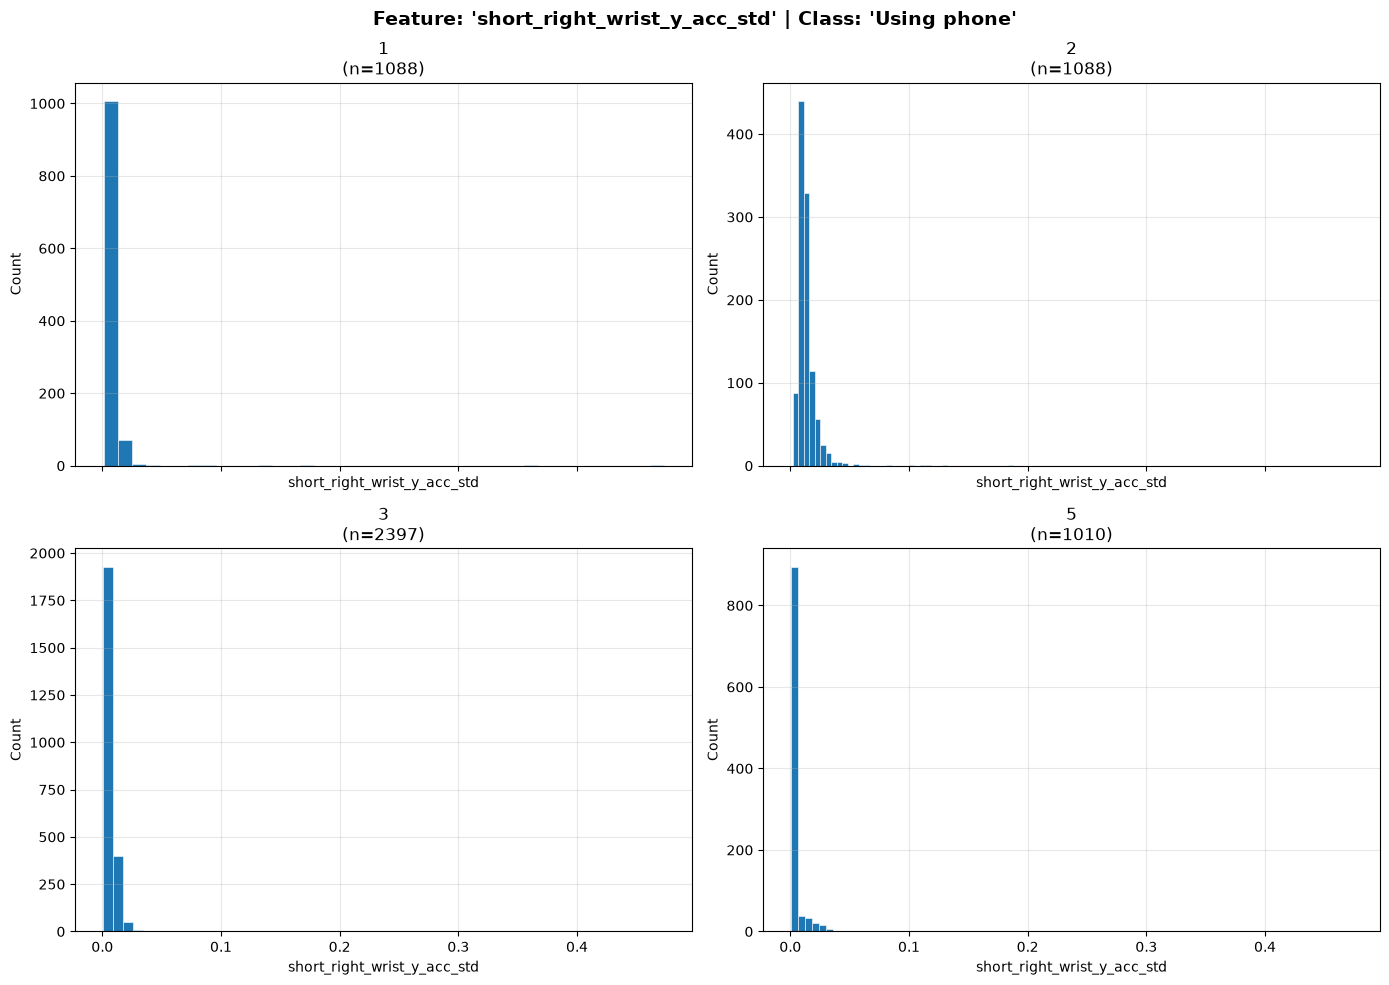

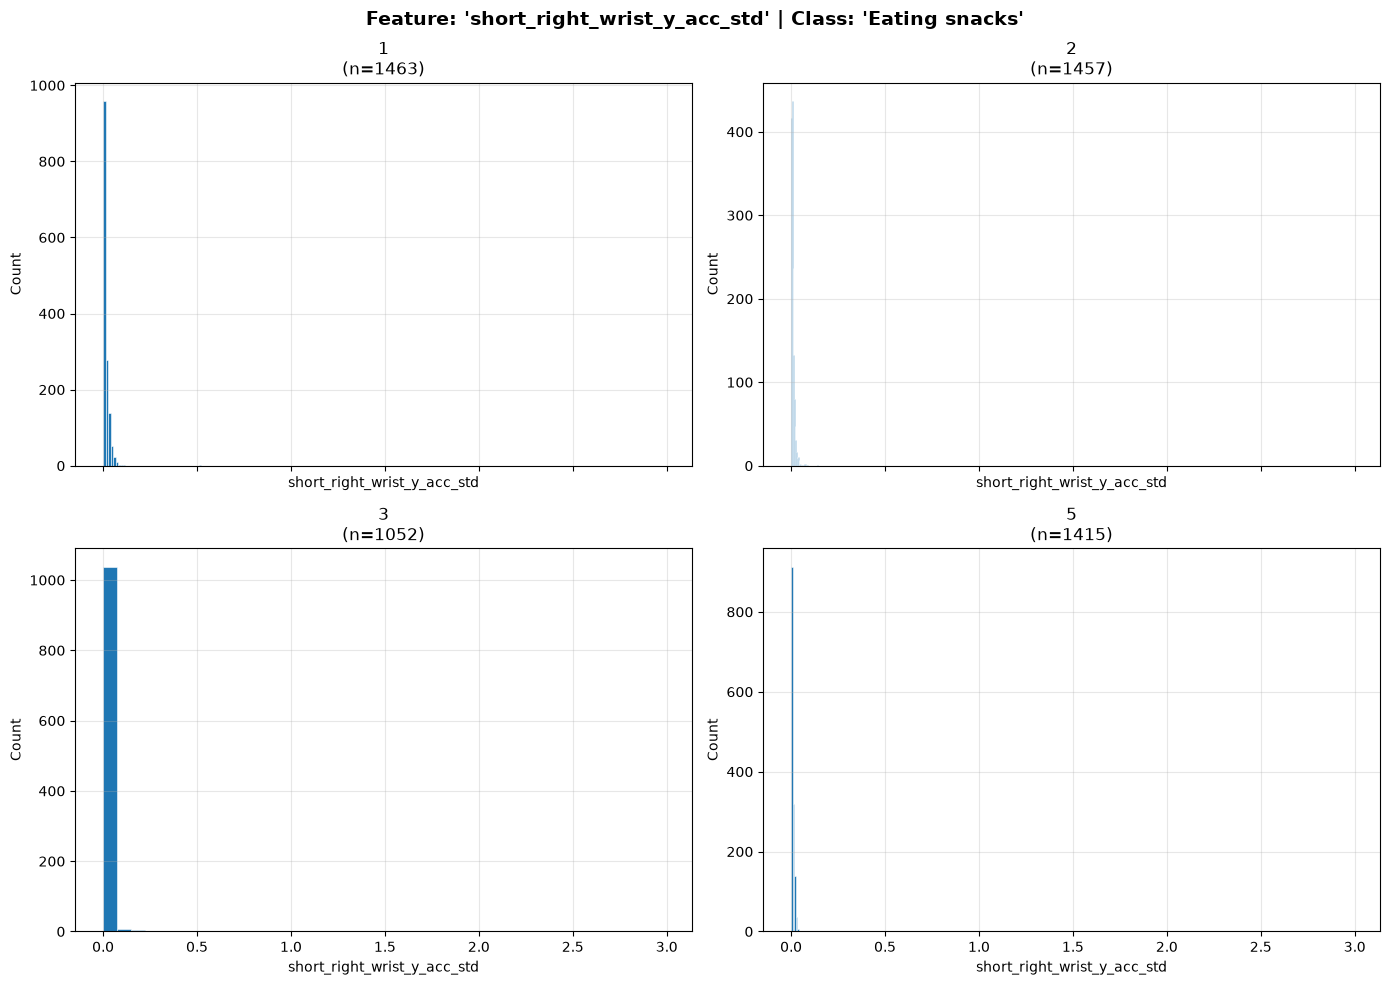

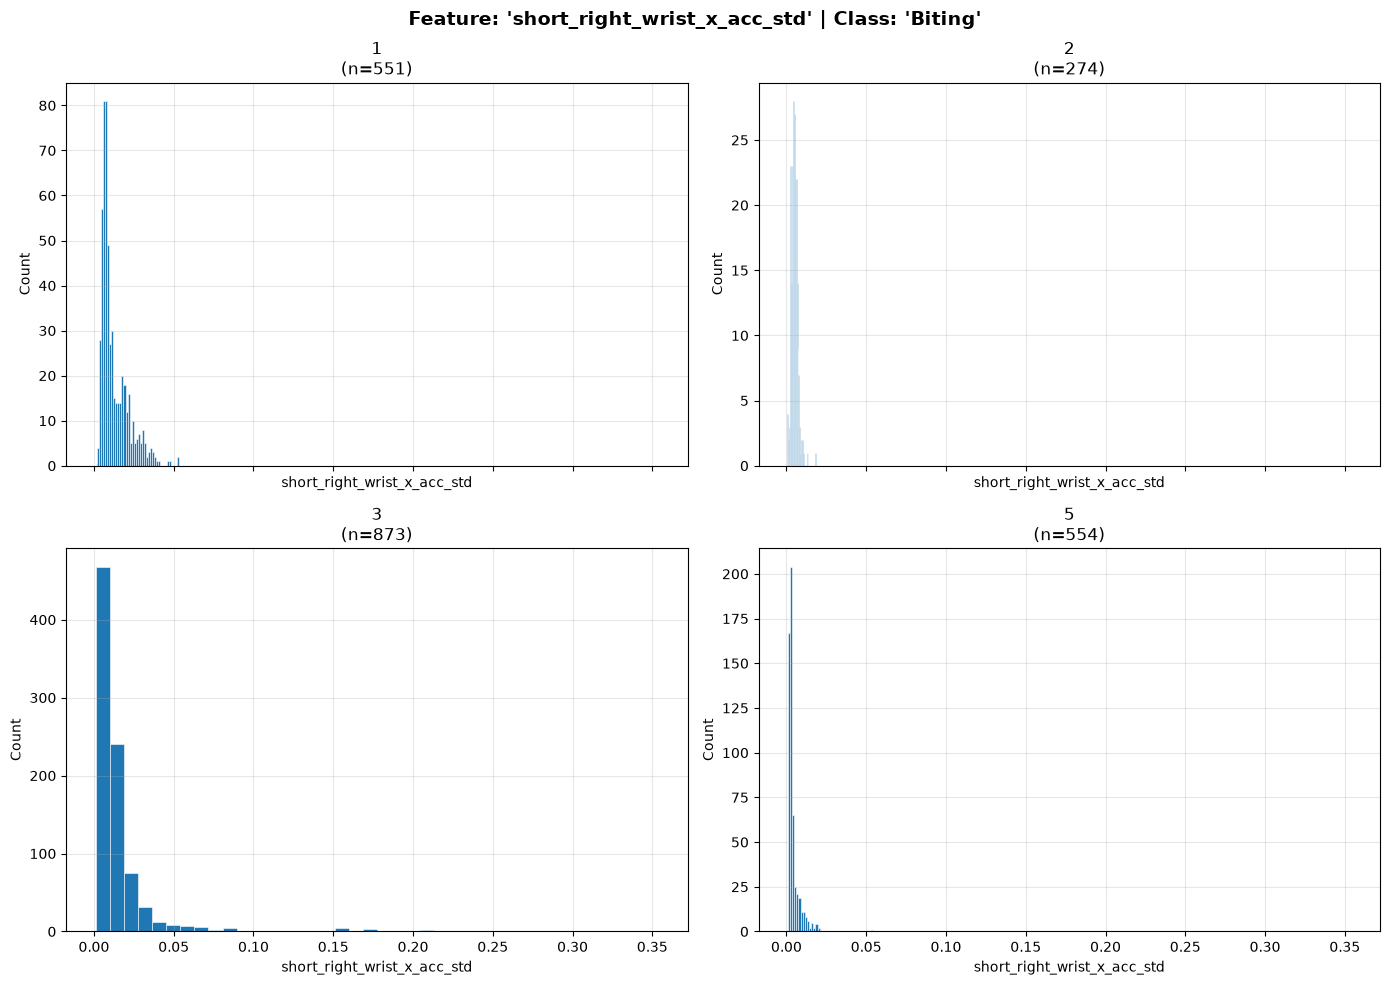

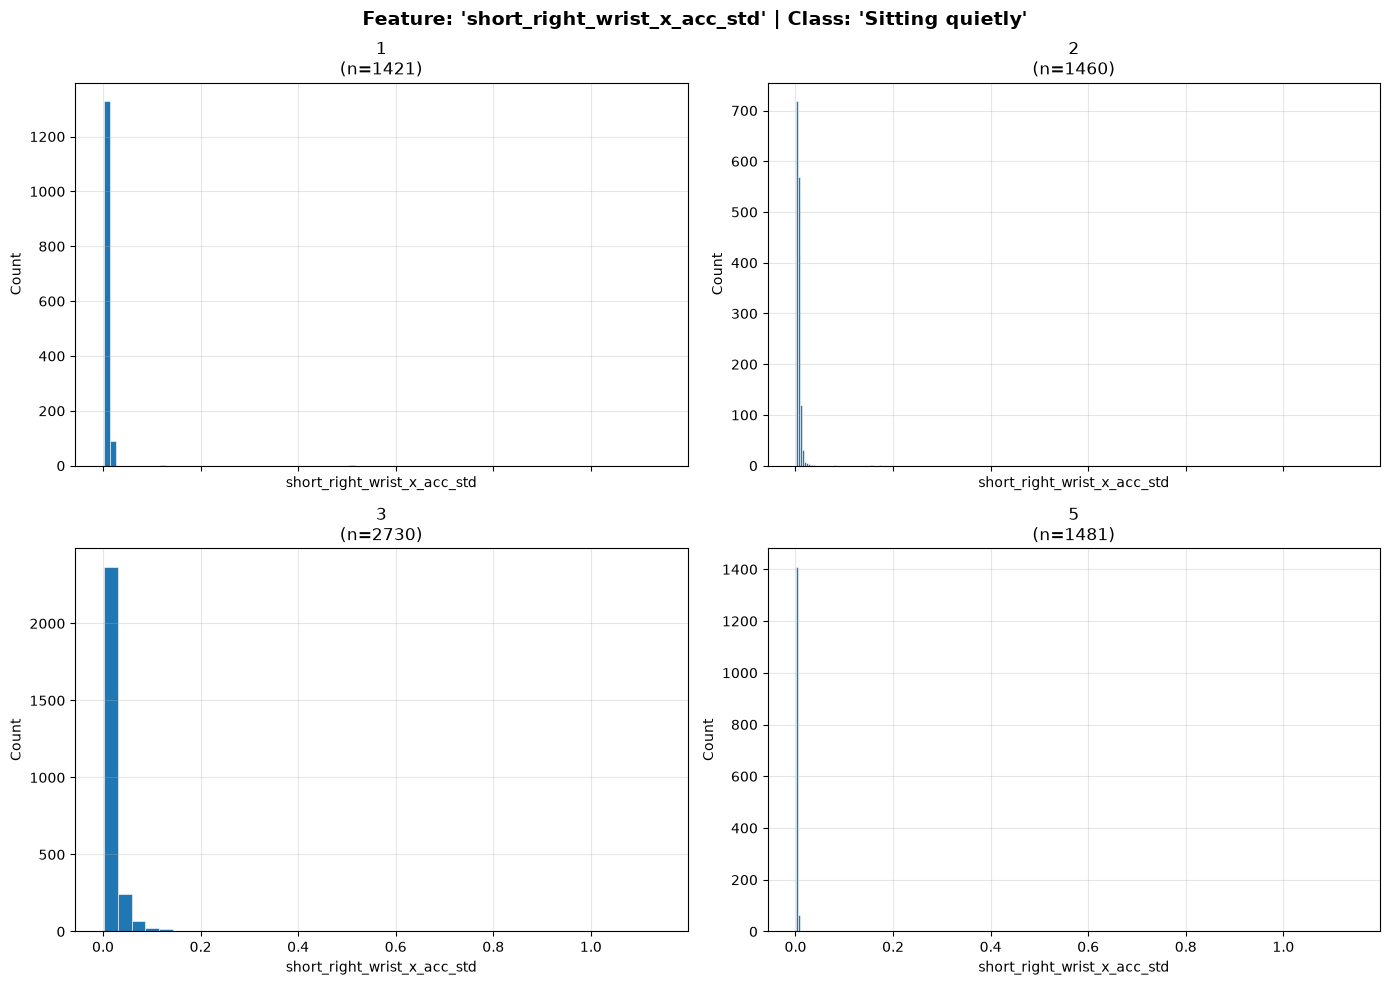

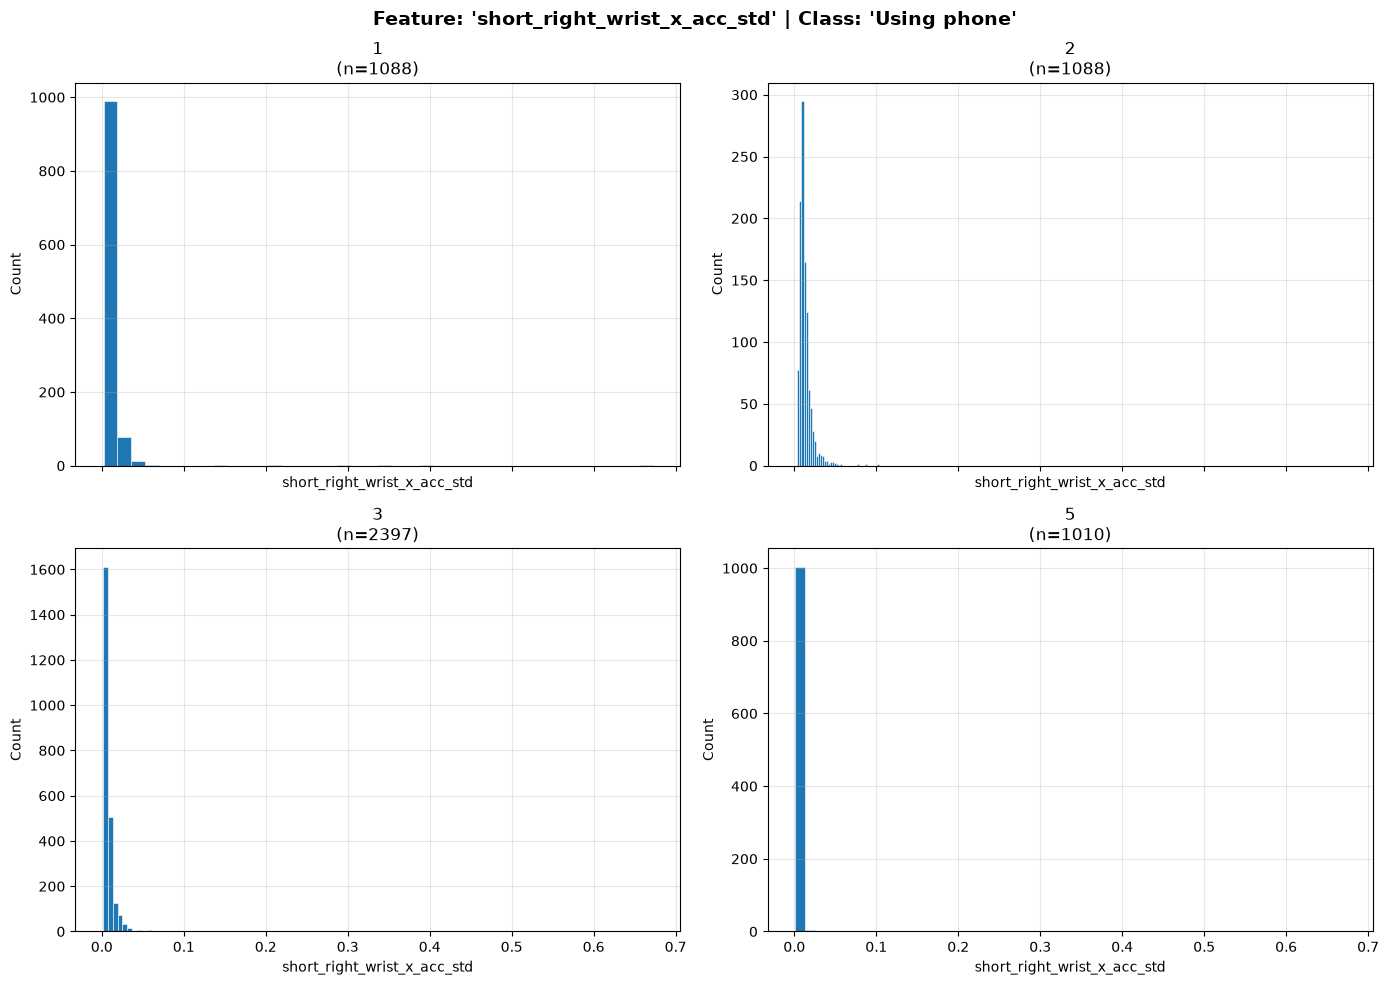

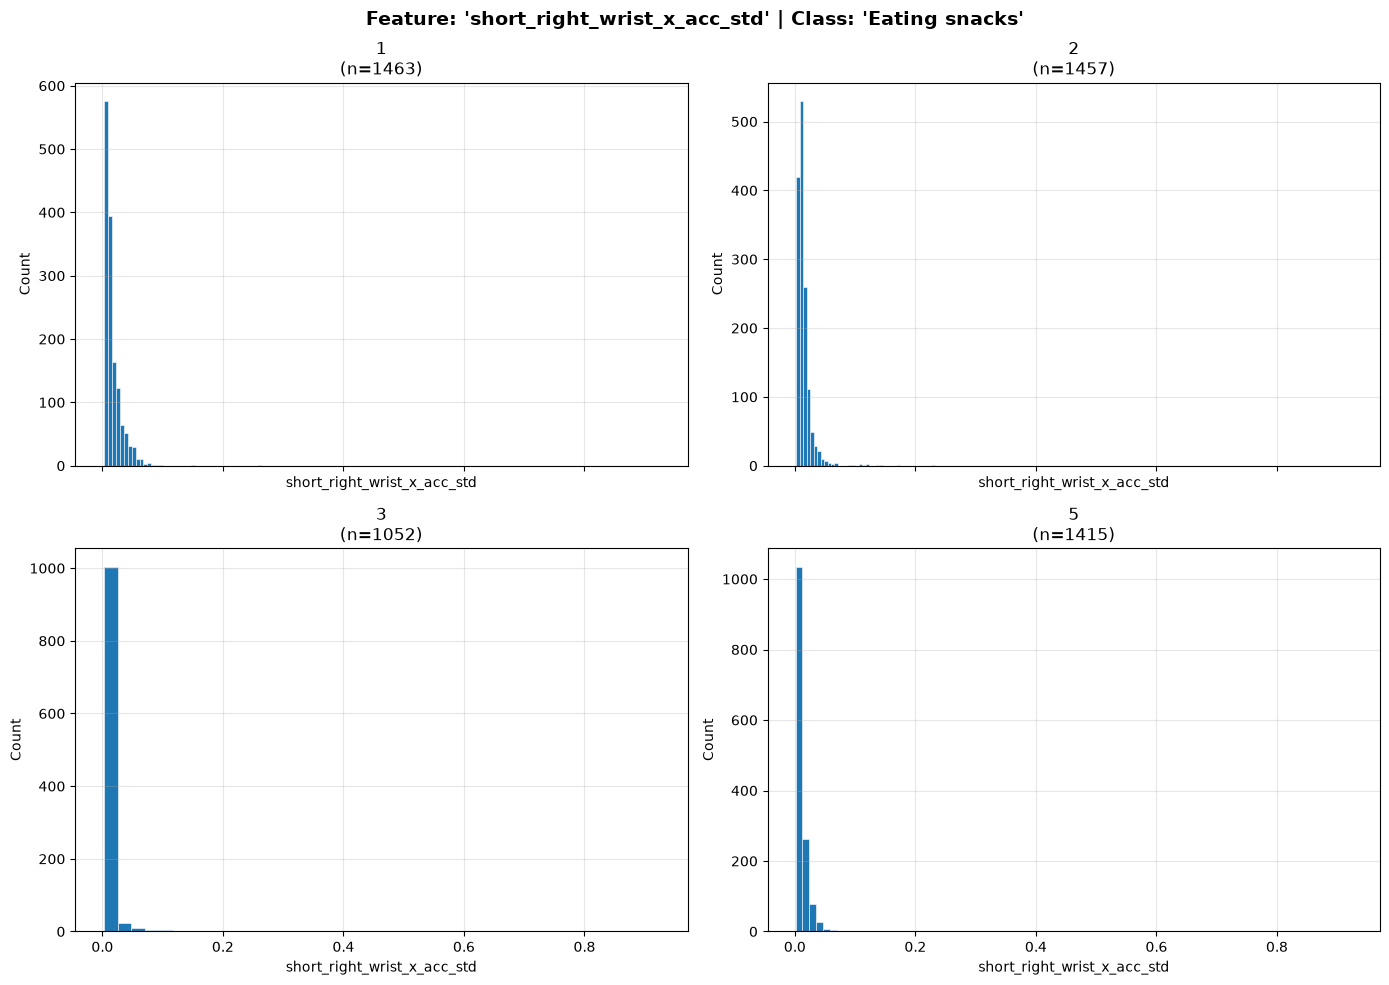

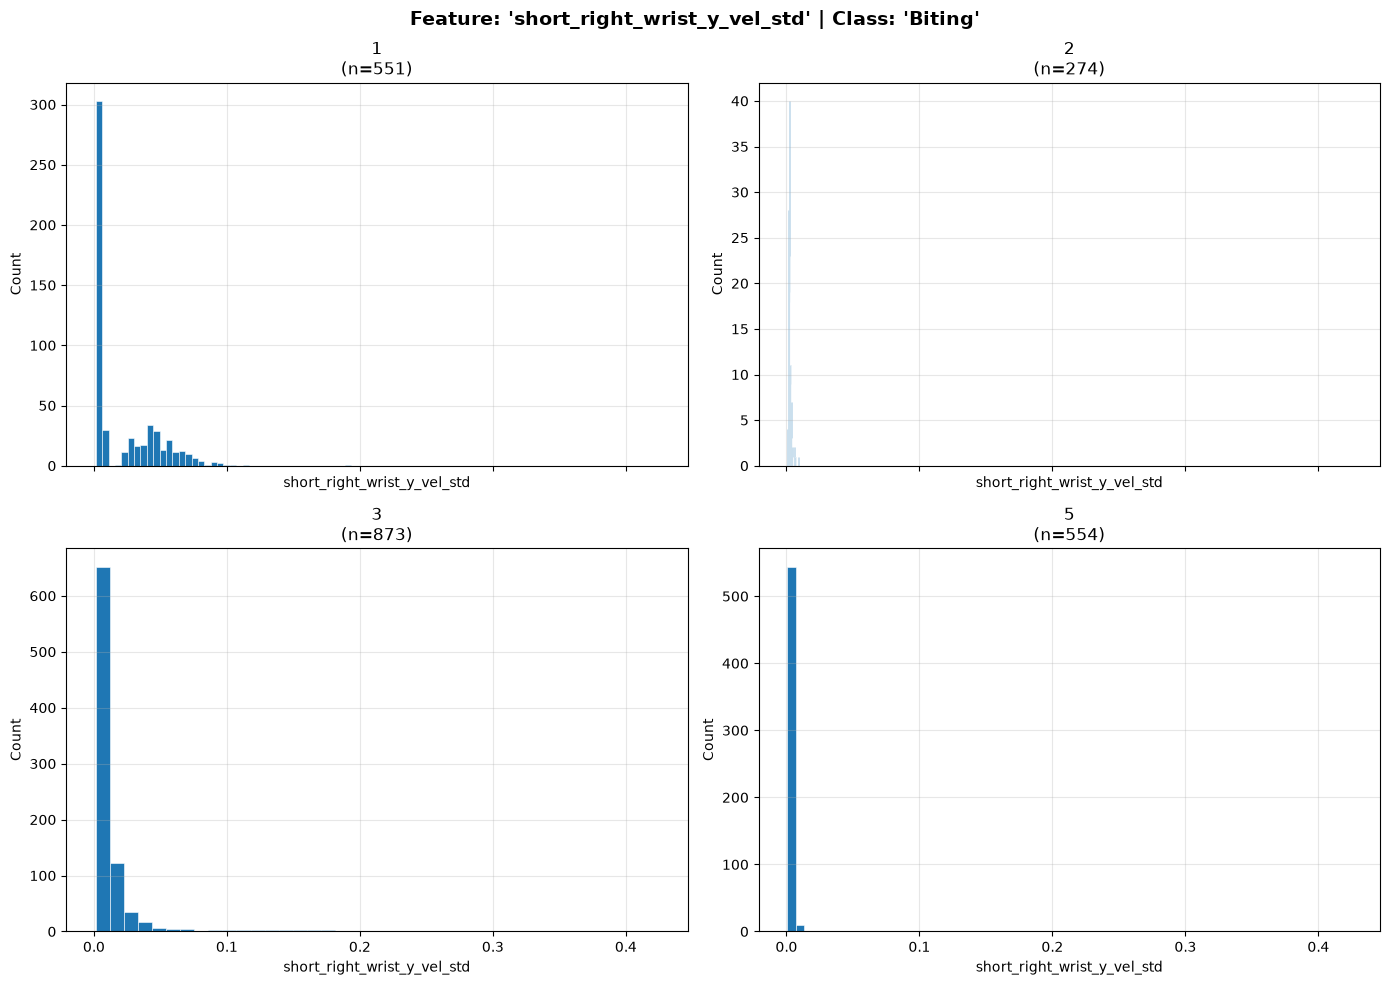

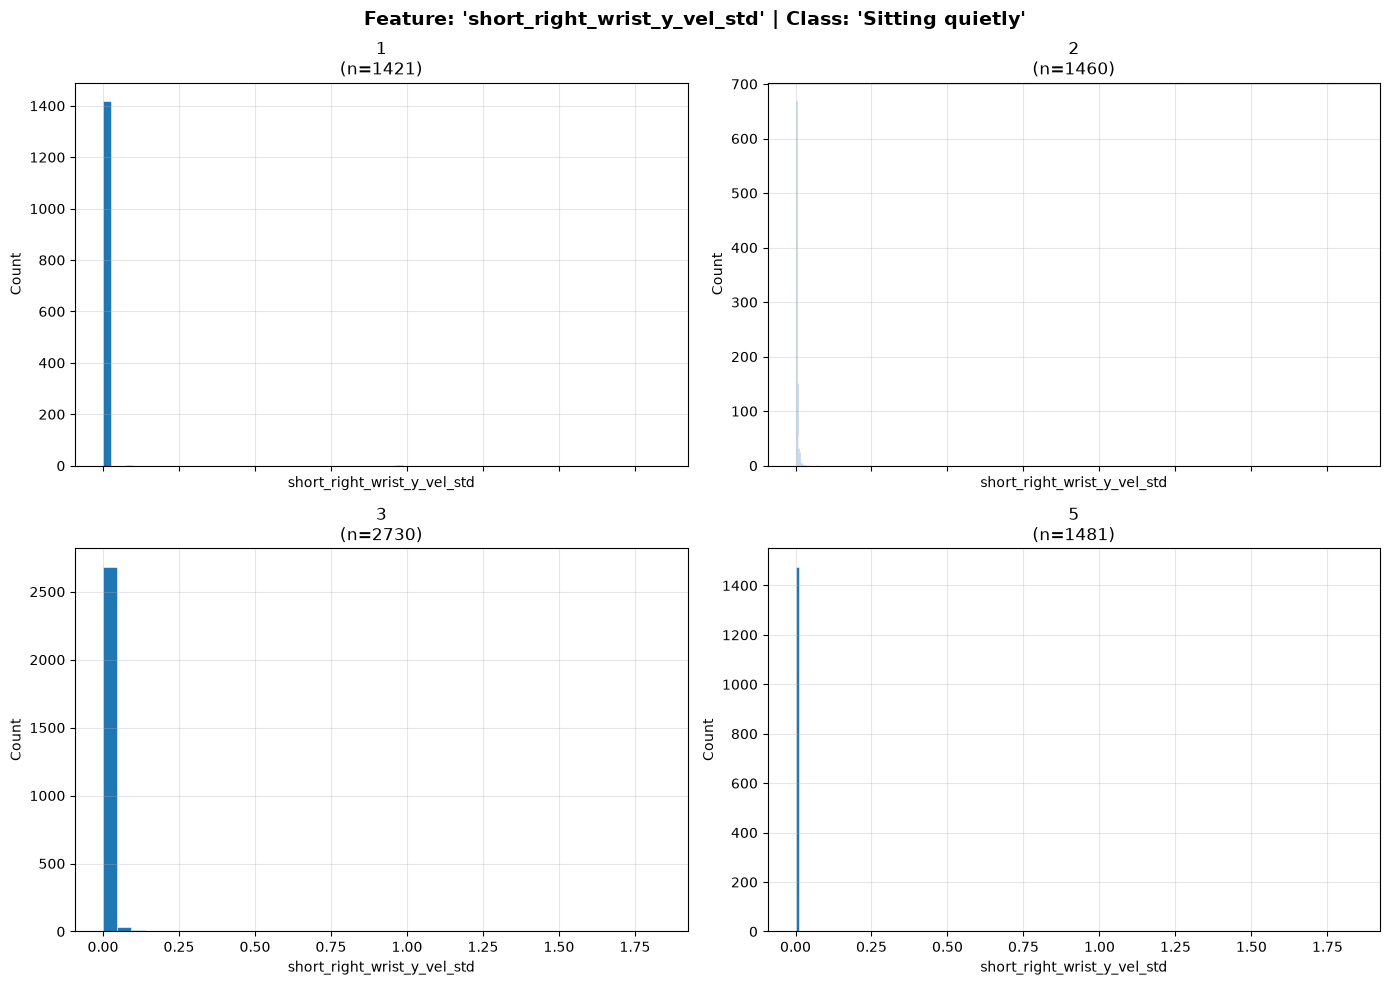

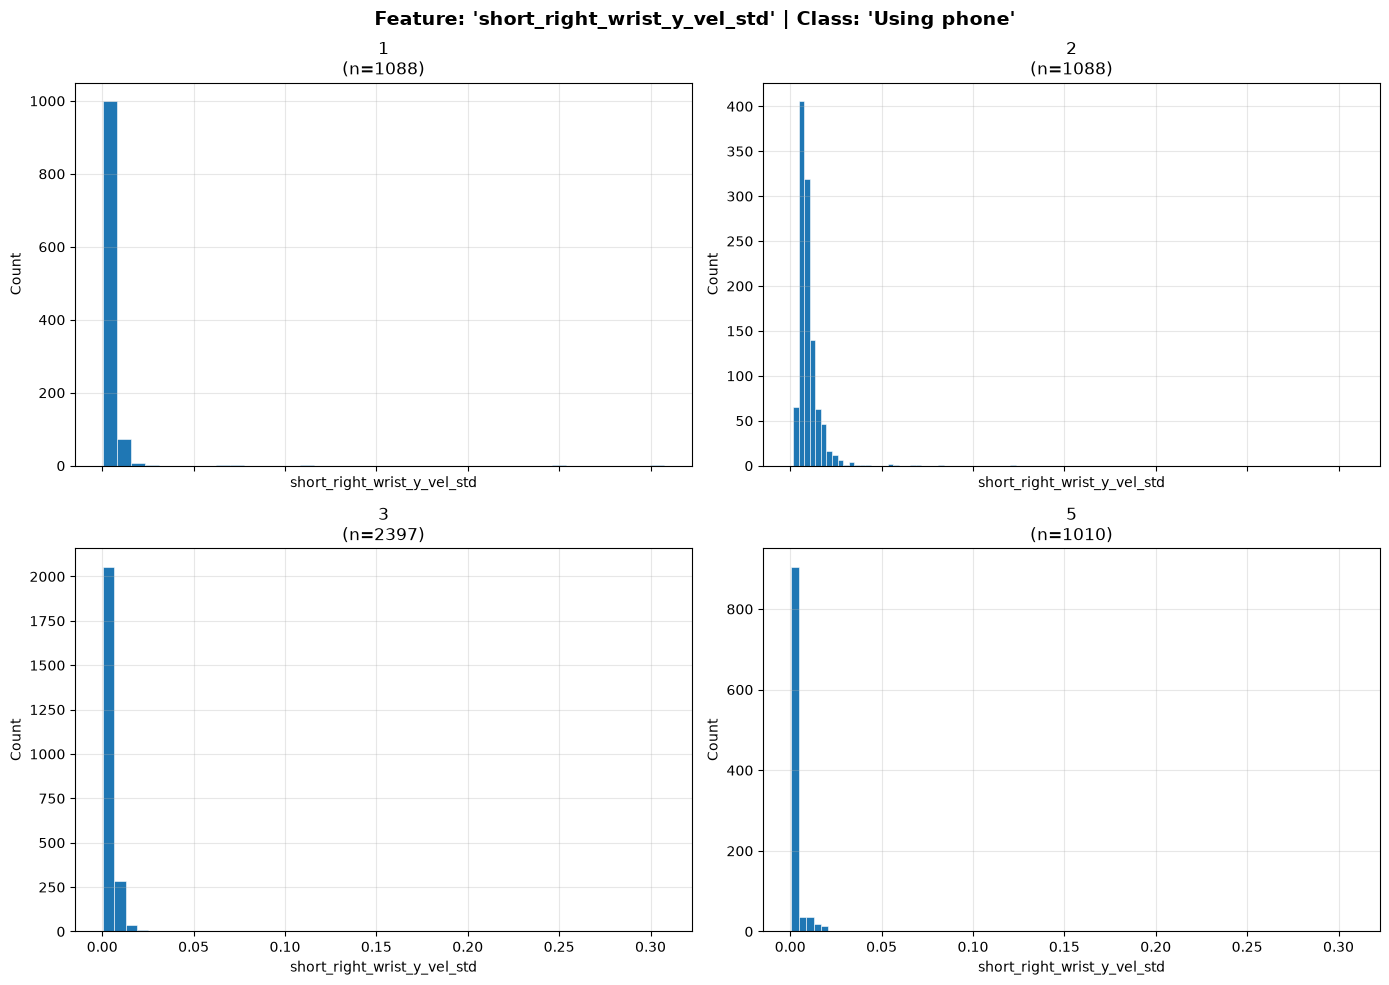

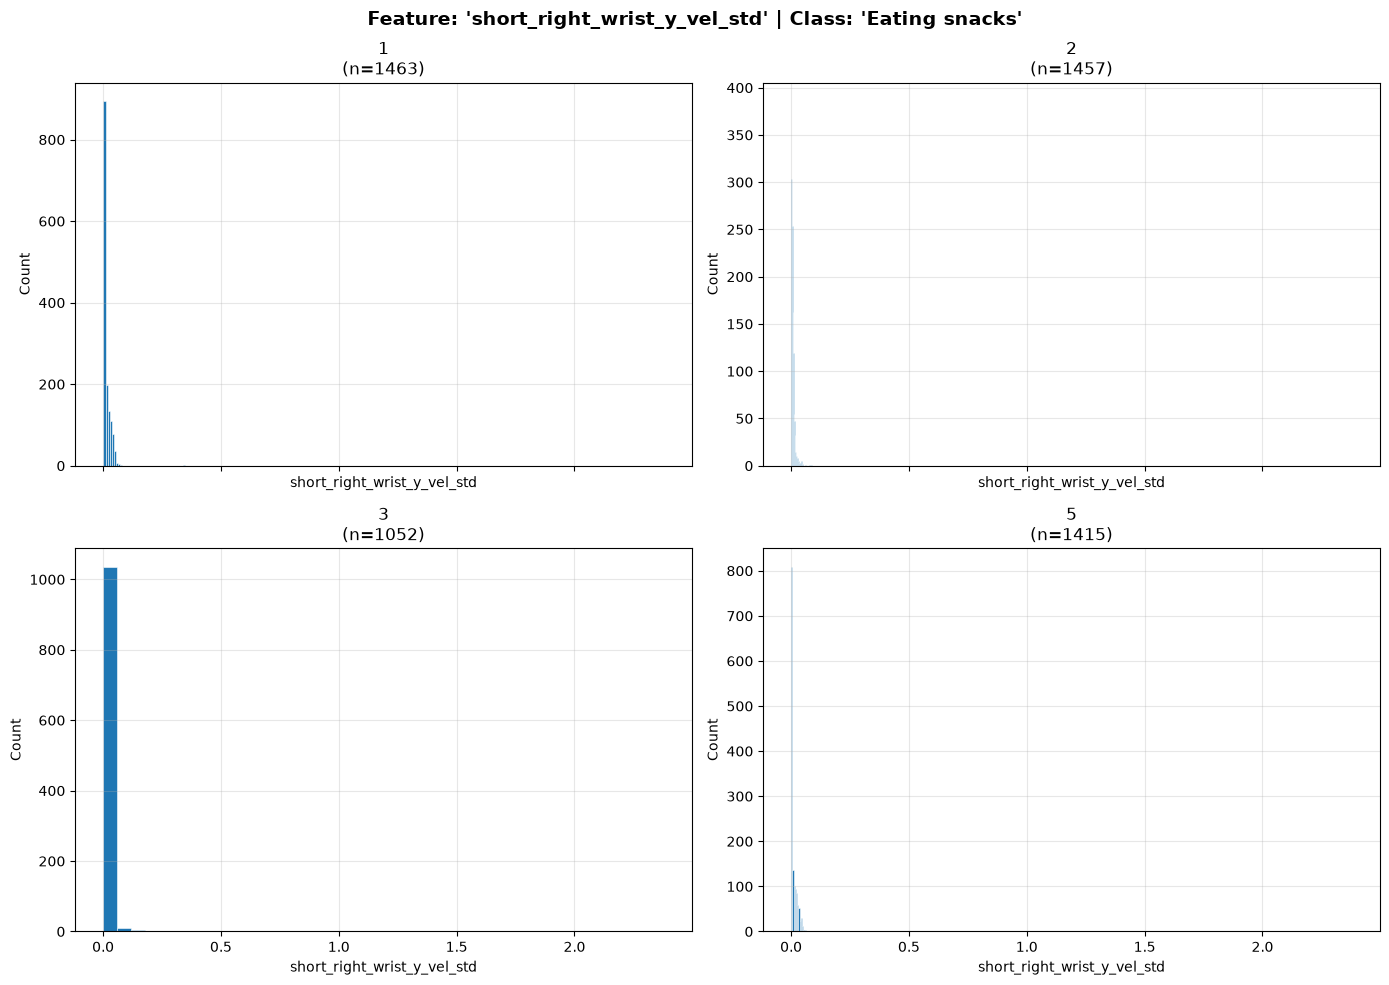

In [49]:
all_subject_norm = preprocess_all_subjects(all_subject=all_subject)

classes_of_interest = [
    'Biting',
    'Sitting quietly',
    'Using phone',
    'Eating snacks'
]

features_of_interest = [

    # Does the hand actually reach the face?
    'short_right_wrist_to_nose_dist_mean',

    # Is the wrist moving while near the face?
    'short_right_wrist_to_nose_dist_std',

    # Phone use usually has a bent elbow.
    'long_angle_right_elbow_mean',

    # Phone and eating differ by elbow motion.
    'long_angle_right_elbow_std',

    # Height of the right hand.
    'long_right_wrist_height_rel_shoulder_mean',

    # Is the hand moving vertically?
    'short_right_wrist_y_acc_std',

    # Horizontal wrist motion.
    'short_right_wrist_x_acc_std',

    # Wrist velocity.
    'short_right_wrist_y_vel_std',
]

for feature in features_of_interest:
    for activity_class in classes_of_interest:
        plot_feature_class_across_subjects(
            subjects_dict=all_subject_norm,
            feature=feature,
            activity_class=activity_class
        )

# Conclusion / 結論

## Feature Engineering Accuracy Summary / 特徴量設計の精度まとめ

This section summarizes the classification accuracy of the baseline Random Forest model across all feature combinations evaluated in this notebook. Features were introduced incrementally to quantify each addition's contribution to human activity recognition performance.

本セクションでは、本ノートブックで評価したすべての特徴量の組み合わせに対するベースライン Random Forest モデルの分類精度をまとめる。

---

### Accuracy Progression by Feature Set / 特徴量セット別の精度推移

| # | Feature Set / 特徴量セット | # Features | Test Accuracy |
|---|---------------------------|-----------|:-------------:|
| 1 | Joint Angles Only / 関節角度のみ | 7 | 0.47 |
| 2 | Normalized Coords + Joint Angles / 正規化座標 + 関節角度 | 41 | 0.48 |
| 3 | ROM Features Only / ROM特徴量のみ | 9 | 0.29 |
| 4 | Normalized Coords + Joint Angles + ROM / 正規化座標 + 関節角度 + ROM | 50 | 0.49 |
| 5 | Velocity & Acceleration Only / 速度・加速度のみ | 68 | 0.47 |
| 6 | Full Frame-level (Coords + Angles + ROM + Vel/Acc) / フレーム単位の完全特徴量 | 118 | 0.49 |
| 7 | Single-scale Window (size=20, stride=10) / 単一時間窓 | 472 | **0.56** |
| 8 | Multi-scale Window (15 & 60, stride=10) / マルチスケール時間窓 | 944 | **0.56** |
| 9 | Single-scale Window (size=20, stride=10) LOSO / 単一時間窓 LOSO | 472 | **0.44** |
| 10 | Multi-scale Window (15 & 60, stride=10) LOSO / マルチスケール時間窓 LOSO | 944 | **0.45** |

---

## Key Findings / 主な発見

**Feature Engineering Impact / 特徴量設計の効果**

- **Joint angles** (0.47) provide a compact, pose-invariant representation that matches raw normalized coordinates in accuracy, but with only 7 features.
- **ROM features alone** (0.29) are insufficient on their own, but when combined with coordinates and angles they push accuracy to 0.49 — suggesting they add complementary, not standalone, information.
- **Velocity & acceleration** (0.47) match angle-only accuracy at the frame level, but crucially capture *motion dynamics* that static posture features cannot — this becomes valuable after windowing.
- **Windowed aggregation** produces the largest single accuracy jump, from 0.49 → **0.56**, by reducing frame noise and encoding temporal statistics.
- **Multi-scale windowing** (15 & 60 frames) matches the single-scale result (0.56) at the default parameters, but captures both short-term and long-term dynamics simultaneously — differences between the two approaches are expected to become more pronounced after window parameter optimization in the next notebook.

**Persistent Classifier Limitations / 残存する分類器の課題**

Across all experiments, **Biting**, **Sitting quietly**, and **Using phone** consistently show near-zero recall. These activities are either under-represented relative to their difficulty, or share highly similar static posture with other classes. Specifically, Biting and Eating snacks produce nearly identical wrist-to-face distances and elbow angles — they are primarily distinguished by *how the hand moves*, not *where it is*. Future work should explore richer temporal descriptors such as wrist speed statistics, hand-to-mouth cycle counts, and oscillation frequency.

---

## Next Steps / 次のステップ

The complete multi-scale windowed feature set will be carried forward into the next notebook, where **window parameter optimization** (short/long window sizes and stride) and **model hyperparameter tuning** will be performed to push recognition performance beyond the current 0.56 baseline.

完全なマルチスケール時間窓特徴量セットを次のノートブックへ引き継ぎ、**時間窓パラメータ最適化**（短時間窓・長時間窓サイズおよびストライド）および**モデルハイパーパラメータチューニング**を実施し、現在のベースライン 0.56 を超える認識性能を目指す。